Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Torch: 2.10.0+cu128

🔧 Pruning Configuration:
   - Target Prune Ratio: 40% (SAME for both approaches)
   - Mode: CONSENSUS (Seeded)
   - Seeds: 4
   - Unimportant = bottom 20% within each seed
   - Agreement needed: 80% of seeds
Dataset split: Train=50000, Val=5000, Test=5000
⚠️  Test set is LOCKED and will only be used for final evaluation
📂 Found existing model at /content/drive/MyDrive/ColabNotebooks/pruned_models/vgg16_cifar10.pth
✅ Loaded seed unknown from 2026-02-26T12:42:08.786279
✅ Using loaded baseline model
📊 Loaded model validation accuracy: 82.84%

📊 Collecting activation scores from VALIDATION set...


Collected scores for 13 layers

✂️ PRUNING WITH TARGET RATIO: 40%

📋 SINGLE MODEL PRUNING:

🔬 CONSENSUS-BASED PRUNING with Enhanced Seed Management:

📚 Seed Management:
   - Requested: 4 seeds
   - Available in drive: 0 seeds []
   - Using all 0 existing seeds: []
   - Training 4 new seeds: [0, 1, 2, 3]

   🌱 Training Seed 0


      Epoch 5/5: Val Acc 74.56%
✅ Model saved to /content/drive/MyDrive/ColabNotebooks/pruned_models/vgg16_cifar10_seed0.pth (seed 0, val_acc: 74.56%)

   🌱 Training Seed 1


      Epoch 5/5: Val Acc 78.90%
✅ Model saved to /content/drive/MyDrive/ColabNotebooks/pruned_models/vgg16_cifar10_seed1.pth (seed 1, val_acc: 78.90%)

   🌱 Training Seed 2


      Epoch 5/5: Val Acc 78.26%
✅ Model saved to /content/drive/MyDrive/ColabNotebooks/pruned_models/vgg16_cifar10_seed2.pth (seed 2, val_acc: 78.26%)

   🌱 Training Seed 3


...

[Consensus] Epoch 6/10 | Train 83.24% | Val 76.96%


[Consensus] Epoch 7/10 | Train 84.44% | Val 83.64%


[Consensus] Epoch 8/10 | Train 85.56% | Val 82.26%


[Consensus] Epoch 9/10 | Train 86.06% | Val 84.52%


[Consensus] Epoch 10/10 | Train 86.62% | Val 84.62%

🎯 FINAL TEST EVALUATION
Test set has been LOCKED and untouched until now...

📈 Baseline Test Accuracy: 83.48%
📈 Single Model Test Accuracy: 83.86%
📈 Consensus Model Test Accuracy: 84.66%

COMPRESSION RESULTS
Baseline params: 33,646,666
Single Model params: 23,420,080
Single Model reduction: 30.39% (target: 40%)
Consensus Model params: 23,420,080
Consensus Model reduction: 30.39% (target: 40%)

📚 SEED MANAGEMENT SUMMARY
   - Requested seeds: 4
   - Seeds used: [0, 1, 2, 3]
   - Newly trained: [0, 1, 2, 3]
   - Loaded from cache: []


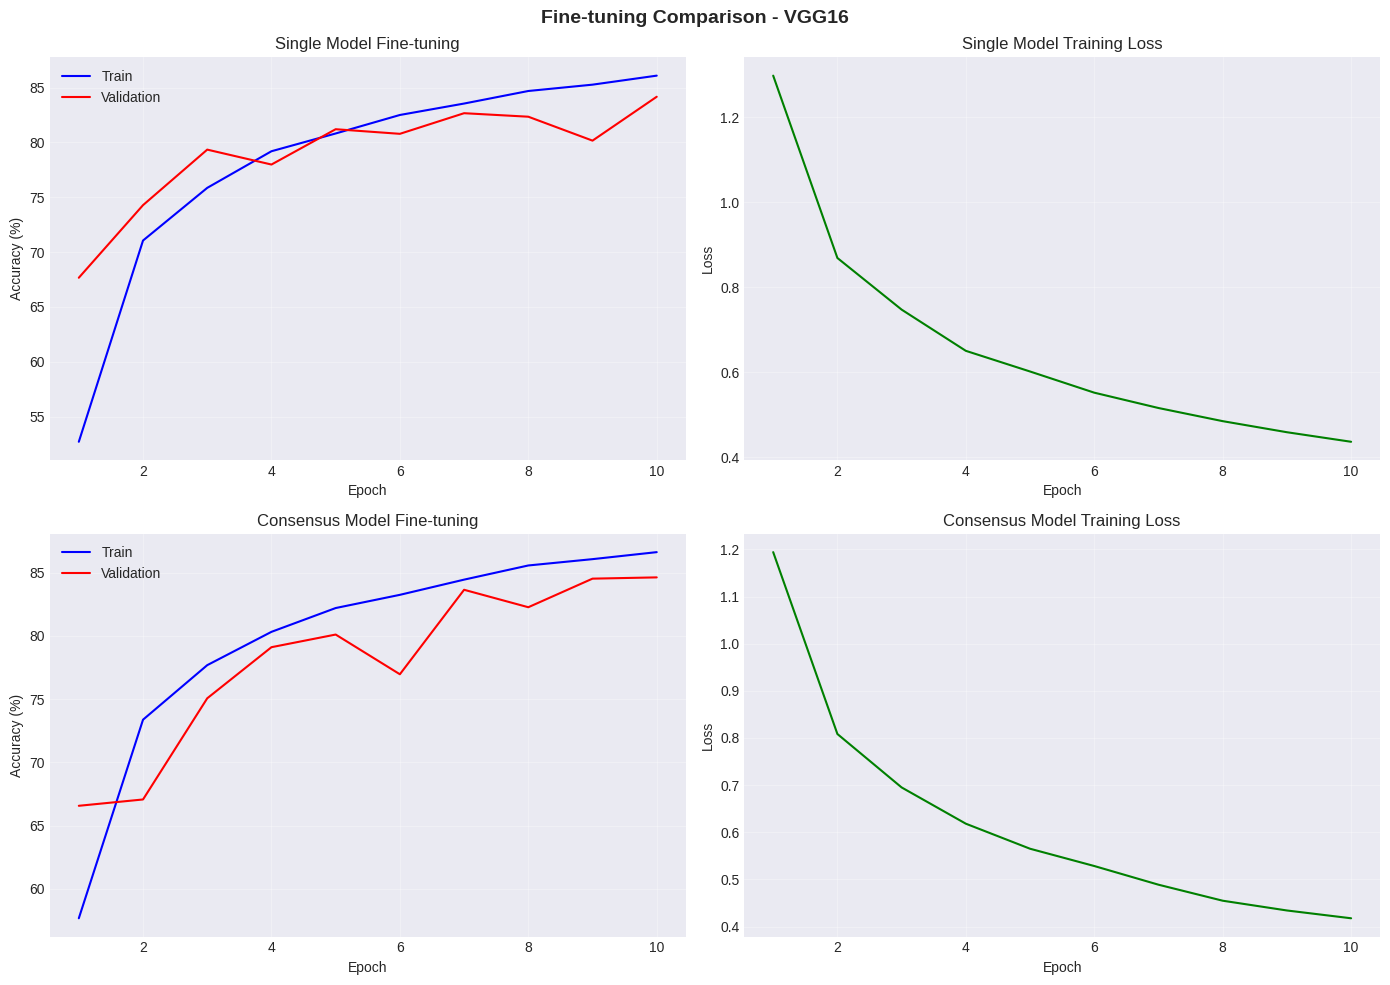

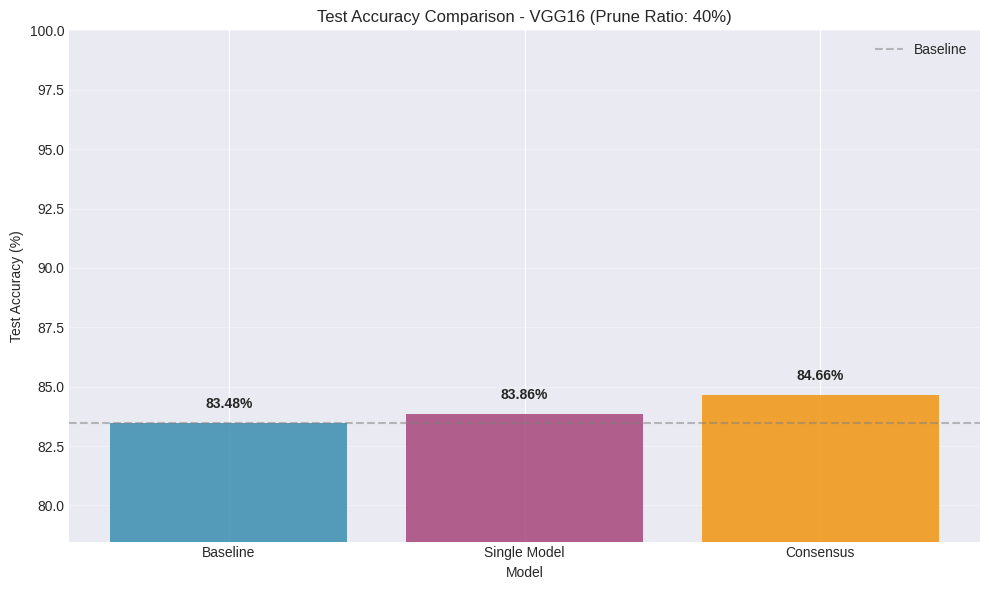


EXPERIMENT SUMMARY

Configuration:
- Model: vgg16
- Dataset: cifar10
- Target Prune Ratio: 40%
- Score Type: mean_act
- Consensus Used: True

Results:
- Baseline Test Accuracy: 83.48%
- Single Model Test Accuracy: 83.86%
- Consensus Model Test Accuracy: 84.66%

Compression:
- Single Model Reduction: 30.39%
- Consensus Model Reduction: 30.39%


📊 Comparison:
   Single vs Baseline: +0.38pp
   Consensus vs Baseline: +1.18pp
   Consensus vs Single: +0.80pp

✅ PIPELINE COMPLETE


In [ ]:
# =========================
# Setup and Imports
# =========================
!pip -q install thop seaborn

import copy, math, random, os, time, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm
from thop import profile, clever_format
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Create necessary directories
Path("sweep_results").mkdir(exist_ok=True)
Path("flops_analysis").mkdir(exist_ok=True)

# =========================
# Colors for plotting
# =========================
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B8F5E']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Torch:", torch.__version__)

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# =========================
# Configuration - COMPARABLE MODES
# =========================
config = {
    # Model and dataset
    'model': 'vgg16',                 # 'vgg16' | 'resnet18' | 'mobilenet_v2'
    'dataset': 'cifar10',             # 'cifar10' | 'catdog'
    'num_classes': 10,                 # Will be auto-set

    # Training parameters
    'batch_size': 128,
    'epochs': 10,                      # Baseline training epochs
    'finetune_epochs': 10,
    'finetune_lr': 1e-3,
    'bn_recalibration_batches': 10,

    # Pruning parameters - SHARED between modes for fair comparison
    'prune_ratio': 0.40,               # SAME ratio for both approaches
    'prune_scope': 'local',             # 'local' | 'global'
    'score_type': 'mean_act',            # Scoring method

    # Consensus parameters (used in seeded approach)
    'use_consensus': True,             # Toggle between single and seeded
    'num_consensus_seeds': 4,           # Number of seeds to train
    'consensus_percentile': 20,         # Bottom X% considered "unimportant" within each seed
    'consensus_agreement': 0.80,         # Must be unimportant in ≥ this fraction of seeds

    # Google Drive save/load
    'save_model': True,
    'model_save_dir': '/content/drive/MyDrive/ColabNotebooks/pruned_models/',
    'force_retrain': False,
    'load_if_exists': True,

    # Test set configuration
    'test_split_ratio': 0.5,            # Fraction of validation set to use as test

    # Visualization
    'plot_training_history': True,
}

print(f"\n🔧 Pruning Configuration:")
print(f"   - Target Prune Ratio: {config['prune_ratio']:.0%} (SAME for both approaches)")
print(f"   - Mode: {'CONSENSUS (Seeded)' if config['use_consensus'] else 'SINGLE (Standard)'}")
if config['use_consensus']:
    print(f"   - Seeds: {config['num_consensus_seeds']}")
    print(f"   - Unimportant = bottom {config['consensus_percentile']}% within each seed")
    print(f"   - Agreement needed: {config['consensus_agreement']:.0%} of seeds")

# =========================
# Scoring Methods Registry
# =========================
SCORING_METHODS = {
    'mean_act': {'type': 'local', 'description': 'Mean absolute activation'},
    'apoz': {'type': 'local', 'description': 'Average percentage of zeros'},
    'activation_variance': {'type': 'local', 'description': 'Variance of activations'},
    'activation_l1': {'type': 'local', 'description': 'L1 norm of feature maps'},
    'entropy': {'type': 'local', 'description': 'Entropy of activation distribution'},
    'global_mean_act': {'type': 'global', 'description': 'Global mean activation ranking'},
    'global_apoz': {'type': 'global', 'description': 'Global APoZ ranking'},
    'nisp': {'type': 'global', 'description': 'NISP-style importance propagation'},
    'taylor_expansion': {'type': 'global', 'description': 'Taylor expansion (activation × gradient)'},
    'global_activation_energy': {'type': 'global', 'description': 'Global squared activation energy'},
}

# =========================
# Dataset Factory with Test Split
# =========================
def get_dataset(config):
    """Factory function to get dataset based on config with train/val/test split"""

    # Define transforms FIRST (before any dataset creation)
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_eval = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    if config['dataset'] == 'cifar10':
        # Get raw datasets without transform first
        trainset_raw = datasets.CIFAR10(root='./data', train=True, download=True)
        testset_raw = datasets.CIFAR10(root='./data', train=False, download=True)

        # Apply transforms
        trainset = datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
        testset_full = datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_eval)

        config['num_classes'] = 10

    elif config['dataset'] == 'catdog':
        print("Using CIFAR-10 cat (class 3) and dog (class 5) as Cat vs Dog dataset")

        # Get raw datasets
        full_trainset = datasets.CIFAR10(root='./data', train=True, download=True)
        full_testset = datasets.CIFAR10(root='./data', train=False, download=True)

        # Filter for cat (3) and dog (5)
        train_indices = [i for i, (_, label) in enumerate(full_trainset) if label in [3, 5]]
        test_indices = [i for i, (_, label) in enumerate(full_testset) if label in [3, 5]]

        # Map labels: cat=3 -> 0, dog=5 -> 1
        def filter_and_transform(dataset, indices, transform):
            images, labels = [], []
            for idx in indices:
                img, label = dataset[idx]
                label = 0 if label == 3 else 1
                # Apply transform immediately
                if transform:
                    img = transform(img)
                images.append(img)
                labels.append(label)

            # Create tensor dataset
            images_tensor = torch.stack(images)
            labels_tensor = torch.tensor(labels)

            return torch.utils.data.TensorDataset(images_tensor, labels_tensor)

        trainset = filter_and_transform(full_trainset, train_indices, transform_train)
        testset_full = filter_and_transform(full_testset, test_indices, transform_eval)
        config['num_classes'] = 2

        print(f"Cat vs Dog: {len(trainset)} training samples, {len(testset_full)} test samples")
    else:
        raise ValueError(f"Unknown dataset: {config['dataset']}")

    # For CIFAR10, split the test set
    if config['dataset'] == 'cifar10':
        # Split testset into validation and test
        total_test = len(testset_full)
        val_size = int(total_test * config.get('test_split_ratio', 0.5))
        test_size = total_test - val_size

        # Create indices for split
        indices = list(range(total_test))
        np.random.shuffle(indices)
        val_indices, test_indices = indices[:val_size], indices[val_size:]

        # Create subset datasets
        val_dataset = Subset(testset_full, val_indices)
        test_dataset = Subset(testset_full, test_indices)
    else:
        # For catdog, already have tensor datasets
        total_test = len(testset_full)
        val_size = int(total_test * config.get('test_split_ratio', 0.5))
        test_size = total_test - val_size

        val_dataset = Subset(testset_full, list(range(val_size)))
        test_dataset = Subset(testset_full, list(range(val_size, total_test)))

    # Create data loaders
    train_loader = DataLoader(trainset, batch_size=config['batch_size'],
                             shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'],
                           shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'],
                            shuffle=False, num_workers=2, pin_memory=True)

    print(f"Dataset split: Train={len(trainset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")
    print(f"⚠️  Test set is LOCKED and will only be used for final evaluation")

    return train_loader, val_loader, test_loader

# Load dataset
train_loader, val_loader, test_loader = get_dataset(config)

# =========================
# ENHANCED Model Save/Load Utilities with Seed Management
# =========================
def get_model_path(config, suffix=""):
    """Generate save path for model"""
    os.makedirs(config['model_save_dir'], exist_ok=True)
    return os.path.join(config['model_save_dir'], f"{config['model']}_{config['dataset']}{suffix}.pth")

def save_model(model, config, suffix="", val_acc=None):
    """Save model with metadata including seed info"""
    path = get_model_path(config, suffix)

    # Extract seed index from suffix if present
    seed_idx = None
    if 'seed' in suffix:
        try:
            seed_idx = int(suffix.split('seed')[-1])
        except:
            pass

    # If val_acc not provided, compute it
    if val_acc is None:
        val_acc = evaluate(model, val_loader)

    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'timestamp': datetime.now().isoformat(),
        'seed_idx': seed_idx,
        'val_acc': val_acc,
        'model_type': config['model'],
        'dataset': config['dataset']
    }, path)
    print(f"✅ Model saved to {path} (seed {seed_idx}, val_acc: {val_acc:.2f}%)")

def load_model_if_exists(adapter, config, suffix=""):
    """Load model if it exists"""
    path = get_model_path(config, suffix)

    if os.path.exists(path) and not config['force_retrain']:
        try:
            print(f"📂 Found existing model at {path}")
            checkpoint = torch.load(path, map_location=device)

            # Verify model and dataset match
            if (checkpoint['config']['model'] == config['model'] and
                checkpoint['config']['dataset'] == config['dataset']):

                model = adapter.build(config['num_classes']).to(device)
                model.load_state_dict(checkpoint['model_state_dict'])

                # Print metadata
                timestamp = checkpoint.get('timestamp', 'unknown')
                val_acc = checkpoint.get('val_acc', 'unknown')
                seed_idx = checkpoint.get('seed_idx', 'unknown')

                print(f"✅ Loaded seed {seed_idx} from {timestamp}")
                if val_acc != 'unknown':
                    print(f"   Val Acc: {val_acc:.2f}%")

                return model, True
            else:
                print(f"⚠️ Saved model is for {checkpoint['config']['model']}/{checkpoint['config']['dataset']}, "
                      f"want {config['model']}/{config['dataset']}")
        except Exception as e:
            print(f"⚠️ Error loading model: {e}")

    return None, False

def get_available_seeds(config):
    """Get list of available seed indices for current model/dataset"""
    seed_dir = config['model_save_dir']
    os.makedirs(seed_dir, exist_ok=True)

    available = []
    pattern = f"{config['model']}_{config['dataset']}_seed"

    for f in os.listdir(seed_dir):
        if f.startswith(pattern) and f.endswith('.pth'):
            try:
                # Extract seed number from filename
                seed_str = f.replace(pattern, '').replace('.pth', '')
                seed_idx = int(seed_str)
                available.append(seed_idx)
            except:
                continue

    return sorted(available)

def get_required_seeds(config, num_needed):
    """
    Determine which seeds to use based on availability
    Returns: (seeds_to_use, seeds_to_train)
    """
    available = get_available_seeds(config)

    print(f"\n📚 Seed Management:")
    print(f"   - Requested: {num_needed} seeds")
    print(f"   - Available in drive: {len(available)} seeds {available}")

    if len(available) >= num_needed:
        # Case 1: Enough seeds available - randomly select
        seeds_to_use = sorted(random.sample(available, num_needed))
        seeds_to_train = []
        print(f"   - Using {num_needed} existing seeds: {seeds_to_use}")
        print(f"   - No new seeds needed")
    else:
        # Case 2: Need more seeds - use all available + train new ones
        num_to_train = num_needed - len(available)
        next_idx = max(available) + 1 if available else 0
        new_seeds = list(range(next_idx, next_idx + num_to_train))

        seeds_to_use = available + new_seeds
        seeds_to_train = new_seeds

        print(f"   - Using all {len(available)} existing seeds: {available}")
        print(f"   - Training {num_to_train} new seeds: {new_seeds}")

    return seeds_to_use, seeds_to_train

# =========================
# Adapter Classes (Preserved)
# =========================
class BaseAdapter:
    def build(self, num_classes): raise NotImplementedError
    def training_recipe(self, model): raise NotImplementedError
    def prunable_layers(self, model): raise NotImplementedError
    def prune(self, model, scores, config): raise NotImplementedError

# ---- VGG16 ----
class VGG16Adapter(BaseAdapter):
    def build(self, num_classes):
        m = models.vgg16_bn(weights=None)
        m.avgpool = nn.AdaptiveAvgPool2d((1,1))
        m.classifier = nn.Sequential(
            nn.Linear(512, 4096), nn.ReLU(True), nn.Dropout(),
            nn.Linear(4096, 4096), nn.ReLU(True), nn.Dropout(),
            nn.Linear(4096, num_classes),
        )
        return m
    def training_recipe(self, model):
        opt = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
        sch = optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.1)
        return opt, sch, config['epochs']
    def prunable_layers(self, model):
        return [(n,m) for n,m in model.named_modules() if isinstance(m, nn.Conv2d)]

    def _build_masks(self, scores, config):
        ratio = config['prune_ratio']; scope = config['prune_scope']
        if scope == 'local':
            masks = {}
            for lname, s in scores.items():
                C = s.numel(); k = int(ratio*C)
                idx = torch.argsort(s)
                keep = torch.ones(C, dtype=torch.bool)
                if k>0: keep[idx[:k]] = False
                masks[lname] = keep
            return masks
        else:
            flat = []
            for lname, s in scores.items():
                for i in range(s.numel()): flat.append((lname, i, float(s[i])))
            flat.sort(key=lambda x: x[2])
            total = len(flat); k = int(ratio*total)
            masks = {lname: torch.ones(scores[lname].numel(), dtype=torch.bool) for lname in scores}
            for n in range(k):
                lname, i, _ = flat[n]; masks[lname][i] = False
            return masks

    def fix_classifier(self, model):
        device_ = next(model.parameters()).device
        with torch.no_grad():
            x = torch.randn(1,3,32,32, device=device_)
            f = model.features(x); f = model.avgpool(f)
            new_dim = f.view(1,-1).shape[1]
        old = model.classifier[0]
        new = nn.Linear(new_dim, old.out_features).to(device_)
        nn.init.kaiming_normal_(new.weight, mode='fan_out', nonlinearity='relu'); nn.init.zeros_(new.bias)
        model.classifier[0] = new

    def prune(self, model, scores, config):
        masks = self._build_masks(scores, config)
        pruned = prune_vgg_structured(model, masks)
        self.fix_classifier(pruned)
        return pruned

# ---- ResNet18 ----
class ResNet18Adapter(BaseAdapter):
    def build(self, num_classes):
        m = models.resnet18(weights=None)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m
    def training_recipe(self, model):
        opt = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
        sch = optim.lr_scheduler.MultiStepLR(opt, milestones=[30,60,80], gamma=0.1)
        return opt, sch, config['epochs']
    def prunable_layers(self, model):
        layers = []
        for n,m in model.named_modules():
            if isinstance(m, nn.Conv2d) and ('layer' in n):
                layers.append((n,m))
        return layers

    def _build_masks(self, scores, config):
        ratio = config['prune_ratio']; scope = config['prune_scope']
        if scope == 'local':
            masks = {}
            for lname, s in scores.items():
                C = s.numel(); k = int(ratio*C)
                idx = torch.argsort(s)
                keep = torch.ones(C, dtype=torch.bool)
                if k > 0:
                    if config.get('score_type') in ['apoz', 'global_apoz']:
                        keep[idx[-k:]] = False
                    else:
                        keep[idx[:k]] = False
                masks[lname] = keep
            return masks
        else:
            flat = []
            for lname, s in scores.items():
                for i in range(s.numel()): flat.append((lname, i, float(s[i])))
            flat.sort(key=lambda x: x[2])
            total = len(flat); k = int(ratio*total)
            masks = {lname: torch.ones(scores[lname].numel(), dtype=torch.bool) for lname in scores}
            for n in range(k):
                lname, i, _ = flat[n]; masks[lname][i] = False
            return masks

    def prune(self, model, scores, config):
        masks = self._build_masks(scores, config)
        pruned = prune_resnet18_structured(model, masks)
        return pruned

# ---- MobileNetV2 ----
class MobileNetV2Adapter(BaseAdapter):
    def build(self, num_classes):
        m = models.mobilenet_v2(weights=None)
        m.classifier[-1] = nn.Linear(m.last_channel, num_classes)
        return m
    def training_recipe(self, model):
        opt = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=4e-5)
        sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=80)
        return opt, sch, config['epochs']
    def prunable_layers(self, model):
        layers = []
        for n,m in model.named_modules():
            if isinstance(m, nn.Conv2d) and m.kernel_size==(1,1): layers.append((n,m))
        return layers

    def _build_masks(self, scores, config):
        ratio = config['prune_ratio']; scope = config['prune_scope']
        if scope == 'local':
            masks = {}
            for lname, s in scores.items():
                C = s.numel(); k = int(ratio*C)
                idx = torch.argsort(s)
                keep = torch.ones(C, dtype=torch.bool)
                if k>0: keep[idx[:k]] = False
                masks[lname] = keep
            return masks
        else:
            flat = []
            for lname, s in scores.items():
                for i in range(s.numel()): flat.append((lname, i, float(s[i])))
            flat.sort(key=lambda x: x[2])
            total = len(flat); k = int(ratio*total)
            masks = {lname: torch.ones(scores[lname].numel(), dtype=torch.bool) for lname in scores}
            for n in range(k):
                lname, i, _ = flat[n]; masks[lname][i] = False
            return masks

    def prune(self, model, scores, config):
        masks = self._build_masks(scores, config)
        pruned = prune_mobilenetv2_structured(model, masks)
        return pruned

def get_adapter(name):
    if name=='vgg16': return VGG16Adapter()
    if name=='resnet18': return ResNet18Adapter()
    if name=='mobilenet_v2': return MobileNetV2Adapter()
    raise ValueError('Unknown model')

# =========================
# Training Utilities
# =========================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    correct=0; total=0; loss_sum=0.0

    for x,y in tqdm(loader, leave=False):
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()*y.size(0)
        pred = out.argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)

    return 100*correct/total, loss_sum/total

@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model on given loader (can be val or test)"""
    model.eval()
    correct=0; total=0

    for x,y in loader:
        x,y = x.to(device), y.to(device)
        out = model(x)
        pred = out.argmax(1)
        correct += (pred==y).sum().item()
        total += y.size(0)

    return 100*correct/total

def train_model(model, train_loader, val_loader, criterion, opt, sch, epochs, history=None):
    """Train model with history tracking"""
    if history is None:
        history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'epochs': []}

    for e in range(epochs):
        tr_acc, tr_loss = train_epoch(model, train_loader, opt, criterion)
        val_acc = evaluate(model, val_loader)
        if sch is not None:
            sch.step()

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(tr_loss)
        history['epochs'].append(len(history['train_acc']))

        print(f"Epoch {e+1}/{epochs} | Train {tr_acc:.2f}% | Val {val_acc:.2f}% | Loss {tr_loss:.4f}")

    return history

def plot_training_history(history, title="Training History"):
    """Plot training and validation accuracy/loss"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    epochs = history['epochs']

    ax1.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
    ax1.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_loss'], 'g-', label='Train Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# =========================
# Scoring Methods Implementation
# =========================
class ActivationCollector:
    def __init__(self):
        self.reset()

    def reset(self):
        self.stats = {}

    def register_hooks(self, model, layers):
        self.reset()
        self.hooks = []

        for name, module in layers:
            def hook_fn(m, i, o, lname=name):
                with torch.no_grad():
                    act = o.detach()

                    mean_abs = act.abs().mean(dim=(0,2,3)).cpu()
                    zero_frac = (act == 0).float().mean(dim=(0,2,3)).cpu()
                    variance = act.var(dim=(0,2,3)).cpu()
                    l1_norm = act.abs().sum(dim=(0,2,3)).cpu()
                    squared_sum = (act ** 2).sum(dim=(0,2,3)).cpu()

                    if lname not in self.stats:
                        self.stats[lname] = {
                            'sum_abs': torch.zeros_like(mean_abs),
                            'sum_zero': torch.zeros_like(zero_frac),
                            'sum_var': torch.zeros_like(variance),
                            'sum_l1': torch.zeros_like(l1_norm),
                            'sum_squared': torch.zeros_like(squared_sum),
                            'batches': 0
                        }

                    self.stats[lname]['sum_abs'] += mean_abs
                    self.stats[lname]['sum_zero'] += zero_frac
                    self.stats[lname]['sum_var'] += variance
                    self.stats[lname]['sum_l1'] += l1_norm
                    self.stats[lname]['sum_squared'] += squared_sum
                    self.stats[lname]['batches'] += 1

            self.hooks.append(module.register_forward_hook(hook_fn))

        return self.hooks

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()
        self.hooks = []

    def compute_scores(self, score_type):
        scores = {}

        for lname, st in self.stats.items():
            b = st['batches']

            if score_type == 'mean_act':
                scores[lname] = st['sum_abs'] / b
            elif score_type == 'apoz':
                scores[lname] = st['sum_zero'] / b
            elif score_type == 'activation_variance':
                scores[lname] = st['sum_var'] / b
            elif score_type == 'activation_l1':
                scores[lname] = st['sum_l1'] / b
            elif score_type == 'entropy':
                scores[lname] = st['sum_var'] / b
            elif score_type == 'global_activation_energy':
                scores[lname] = st['sum_squared'] / b
            elif score_type in ['global_mean_act', 'global_apoz', 'nisp', 'taylor_expansion']:
                if 'global_mean_act' in score_type:
                    scores[lname] = st['sum_abs'] / b
                elif 'global_apoz' in score_type:
                    scores[lname] = st['sum_zero'] / b
                else:
                    scores[lname] = st['sum_abs'] / b
            else:
                raise ValueError(f"Unknown score type: {score_type}")

        return scores

def compute_nisp_scores(model, val_loader, prunable_layers, device):
    model.eval()
    importance_scores = {name: None for name, _ in prunable_layers}

    gradients = {}
    activations = {}

    def forward_hook(name):
        def hook(module, input, output):
            activations[name] = output.detach()
        return hook

    def backward_hook(name):
        def hook(module, grad_input, grad_output):
            if grad_output[0] is not None:
                gradients[name] = grad_output[0].detach()
        return hook

    hooks = []
    for name, module in prunable_layers:
        hooks.append(module.register_forward_hook(forward_hook(name)))
        hooks.append(module.register_full_backward_hook(backward_hook(name)))

    x, y = next(iter(val_loader))
    x, y = x.to(device), y.to(device)

    out = model(x)
    loss = out.mean()

    model.zero_grad()
    loss.backward()

    for name, _ in prunable_layers:
        if name in activations and name in gradients:
            act = activations[name]
            grad = gradients[name]
            importance = (act * grad).abs().mean(dim=(0,2,3)).cpu()
            importance_scores[name] = importance

    for h in hooks:
        h.remove()

    for name, _ in prunable_layers:
        if importance_scores[name] is None:
            importance_scores[name] = torch.ones(1)

    return importance_scores

def compute_taylor_scores(model, val_loader, prunable_layers, device):
    return compute_nisp_scores(model, val_loader, prunable_layers, device)

# =========================
# Consensus Pruning Functions - WITH ENHANCED SEED MANAGEMENT
# =========================
def load_or_train_consensus_seeds(adapter, config, train_loader, val_loader):
    """
    Load or train consensus seeds based on availability
    Returns: list of score dicts, list of seed indices used
    """
    num_needed = config['num_consensus_seeds']
    seeds_to_use, seeds_to_train = get_required_seeds(config, num_needed)

    all_scores = []
    models = []
    base_seed = config.get('seed', 42)

    for seed_idx in seeds_to_use:
        suffix = f"_seed{seed_idx}"
        current_seed = base_seed + seed_idx * 100

        print(f"\n   {'📂 Loading' if seed_idx not in seeds_to_train else '🌱 Training'} Seed {seed_idx}")

        # Set seed for reproducibility
        torch.manual_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        if seed_idx not in seeds_to_train:
            # Load existing model
            model, loaded = load_model_if_exists(adapter, config, suffix=suffix)
            if not loaded:
                raise RuntimeError(f"Seed {seed_idx} claimed available but couldn't be loaded!")
        else:
            # Train new model
            model = adapter.build(config['num_classes']).to(device)
            opt, sch, E = adapter.training_recipe(model)

            # Train for fewer epochs for speed
            train_epochs = min(E, 5)
            for e in range(train_epochs):
                tr_acc, tr_loss = train_epoch(model, train_loader, opt, nn.CrossEntropyLoss())
                val_acc = evaluate(model, val_loader)
                if sch: sch.step()
                if (e+1) % 5 == 0:
                    print(f"      Epoch {e+1}/{train_epochs}: Val Acc {val_acc:.2f}%")

            # Save the trained model
            if config['save_model']:
                val_acc = evaluate(model, val_loader)
                save_model(model, config, suffix=suffix, val_acc=val_acc)

        # Collect scores (always do this, whether loaded or trained)
        collector = ActivationCollector()
        layers = adapter.prunable_layers(model)
        collector.register_hooks(model, layers)

        model.eval()
        with torch.no_grad():
            for x,_ in val_loader:
                _ = model(x.to(device))

        collector.remove_hooks()

        if config['score_type'] in ['nisp', 'taylor_expansion']:
            if config['score_type'] == 'nisp':
                scores = compute_nisp_scores(model, val_loader, layers, device)
            else:
                scores = compute_taylor_scores(model, val_loader, layers, device)
        else:
            scores = collector.compute_scores(config['score_type'])

        all_scores.append(scores)
        models.append(model)

    return all_scores, models, seeds_to_use, seeds_to_train

def build_consensus_masks_with_ratio(all_scores, config):
    """
    Build pruning masks that achieve the target prune_ratio
    by selecting the most consistently unimportant channels
    """
    num_seeds = len(all_scores)
    layer_names = all_scores[0].keys()
    consensus_masks = {}

    percentile = config['consensus_percentile']
    agreement_threshold = config['consensus_agreement']
    target_ratio = config['prune_ratio']

    print(f"\n🔍 Building consensus masks for target ratio {target_ratio:.0%}:")
    print(f"   - Unimportant candidate = bottom {percentile}% within each seed")
    print(f"   - Agreement needed: {agreement_threshold:.0%} of seeds")

    total_pruned = 0
    total_channels = 0

    for layer in layer_names:
        # Stack scores from all seeds
        layer_scores = torch.stack([scores[layer] for scores in all_scores])

        # Calculate average importance across seeds
        avg_importance = layer_scores.mean(dim=0)

        # Calculate agreement score (how many seeds consider this channel unimportant)
        agreement_score = torch.zeros(layer_scores.shape[1])
        threshold_idx = max(1, int(len(layer_scores[0]) * (percentile / 100)))

        for seed_idx in range(num_seeds):
            seed_scores = layer_scores[seed_idx]
            _, unimportant_indices = torch.topk(seed_scores, threshold_idx, largest=False)
            agreement_score[unimportant_indices] += 1

        agreement_score = agreement_score / num_seeds

        # Create a combined score: higher avg_importance AND higher agreement = more prune-worthy
        # Normalize importance to [0,1] range
        imp_min, imp_max = avg_importance.min(), avg_importance.max()
        if imp_max > imp_min:
            norm_importance = (avg_importance - imp_min) / (imp_max - imp_min)
        else:
            norm_importance = torch.zeros_like(avg_importance)

        # Combined score: importance * agreement
        # Higher score = better to prune (high importance = unimportant, high agreement = consistent)
        combined_score = norm_importance * agreement_score

        # Select top k channels to prune based on combined score
        k = int(target_ratio * len(combined_score))
        _, prune_indices = torch.topk(combined_score, k, largest=True)

        # Create mask (True = keep, False = prune)
        mask = torch.ones(len(combined_score), dtype=torch.bool)
        mask[prune_indices] = False

        consensus_masks[layer] = mask

        layer_pruned = len(prune_indices)
        layer_total = len(mask)
        total_pruned += layer_pruned
        total_channels += layer_total

        print(f"   Layer {layer}: pruning {layer_pruned}/{layer_total} channels ({layer_pruned/layer_total*100:.1f}%)")

    overall_ratio = total_pruned / total_channels if total_channels > 0 else 0
    print(f"\n📊 Consensus pruning overall: {total_pruned}/{total_channels} channels ({overall_ratio*100:.1f}%)")
    print(f"   Target ratio: {target_ratio:.0%} | Achieved: {overall_ratio:.1%}")

    return consensus_masks

# =========================
# Pruning Functions
# =========================
def prune_vgg_structured(model, masks):
    new_model = copy.deepcopy(model)
    device_ = next(new_model.parameters()).device
    prev_keep = None
    conv_names = [n for n,m in new_model.named_modules() if isinstance(m, nn.Conv2d)]
    conv_idx = 0

    for name, module in new_model.named_modules():
        if isinstance(module, nn.Conv2d):
            lname = conv_names[conv_idx]; conv_idx += 1
            if lname not in masks:
                prev_keep = None
                continue
            keep = masks[lname].to(device_)
            out_idx = torch.where(keep)[0]

            w = module.weight.data[out_idx].clone()
            if prev_keep is not None:
                in_idx = torch.where(prev_keep)[0]
                w = w[:, in_idx].clone()

            new_conv = nn.Conv2d(w.shape[1], w.shape[0], module.kernel_size,
                                module.stride, module.padding, module.dilation,
                                module.groups, bias=(module.bias is not None)).to(device_)
            new_conv.weight.data.copy_(w)
            if module.bias is not None:
                new_conv.bias.data.copy_(module.bias.data[out_idx].to(device_))

            parent = new_model
            parts = name.split('.')
            for p in parts[:-1]:
                parent = getattr(parent, p)
            setattr(parent, parts[-1], new_conv)
            prev_keep = keep.clone()

        elif isinstance(module, nn.BatchNorm2d) and prev_keep is not None:
            idx = torch.where(prev_keep)[0]
            new_bn = nn.BatchNorm2d(len(idx)).to(device_)
            new_bn.weight.data.copy_(module.weight.data[idx].to(device_))
            new_bn.bias.data.copy_(module.bias.data[idx].to(device_))
            new_bn.running_mean.data.copy_(module.running_mean[idx].to(device_))
            new_bn.running_var.data.copy_(module.running_var[idx].to(device_))

            parent = new_model
            parts = name.split('.')
            for p in parts[:-1]:
                parent = getattr(parent, p)
            setattr(parent, parts[-1], new_bn)

    return new_model

def prune_resnet18_structured(model, masks):
    new_model = copy.deepcopy(model)
    device_ = next(new_model.parameters()).device

    for layer_name in ['layer1','layer2','layer3','layer4']:
        layer = getattr(new_model, layer_name)
        for bi, block in enumerate(layer):
            name1 = f"{layer_name}.{bi}.conv1"
            if name1 in masks:
                keep = masks[name1].to(device_)
                idx = torch.where(keep)[0]

                w1 = block.conv1.weight.data[idx].clone()
                new_c1 = nn.Conv2d(block.conv1.in_channels, w1.shape[0],
                                  block.conv1.kernel_size, block.conv1.stride,
                                  block.conv1.padding, bias=False).to(device_)
                new_c1.weight.data.copy_(w1)
                block.conv1 = new_c1

                bn = block.bn1
                new_bn1 = nn.BatchNorm2d(len(idx)).to(device_)
                new_bn1.weight.data.copy_(bn.weight.data[idx].to(device_))
                new_bn1.bias.data.copy_(bn.bias.data[idx].to(device_))
                new_bn1.running_mean.data.copy_(bn.running_mean[idx].to(device_))
                new_bn1.running_var.data.copy_(bn.running_var[idx].to(device_))
                block.bn1 = new_bn1

                w2 = block.conv2.weight.data[:, idx].clone()
                new_c2 = nn.Conv2d(w2.shape[1], block.conv2.out_channels,
                                  block.conv2.kernel_size, block.conv2.stride,
                                  block.conv2.padding, bias=False).to(device_)
                new_c2.weight.data.copy_(w2)
                block.conv2 = new_c2

    return new_model

def prune_mobilenetv2_structured(model, masks):
    new_model = copy.deepcopy(model)
    device_ = next(new_model.parameters()).device

    for name, module in new_model.named_modules():
        if module.__class__.__name__ != "InvertedResidual":
            continue

        block = module
        layers = block.conv

        if len(layers) == 8:
            # With expansion
            expand_conv_name = name + ".conv.0"
            pw1, bn1 = layers[0], layers[1]
            dw, bn2 = layers[3], layers[4]
            pw2, bn3 = layers[6], layers[7]
        elif len(layers) == 5:
            # Without expansion
            expand_conv_name = name + ".conv.3"
            dw, bn2 = layers[0], layers[1]
            pw2, bn3 = layers[3], layers[4]
        else:
            continue

        if expand_conv_name not in masks:
            continue

        keep = masks[expand_conv_name].to(device_)
        out_idx = torch.where(keep)[0]

        if len(layers) == 8:
            # Prune first pointwise
            w1 = pw1.weight.data[out_idx].clone()
            new_pw1 = nn.Conv2d(pw1.in_channels, len(out_idx), 1,
                               stride=pw1.stride, padding=0, bias=False).to(device_)
            new_pw1.weight.data.copy_(w1)

            new_bn1 = nn.BatchNorm2d(len(out_idx)).to(device_)
            for attr in ['weight', 'bias', 'running_mean', 'running_var']:
                getattr(new_bn1, attr).data.copy_(getattr(bn1, attr).data[out_idx])

            layers[0] = new_pw1
            layers[1] = new_bn1

        # Prune depthwise
        w_dw = dw.weight.data[out_idx].clone()
        new_dw = nn.Conv2d(len(out_idx), len(out_idx), dw.kernel_size,
                          stride=dw.stride, padding=dw.padding,
                          groups=len(out_idx), bias=False).to(device_)
        new_dw.weight.data.copy_(w_dw)

        new_bn2 = nn.BatchNorm2d(len(out_idx)).to(device_)
        for attr in ['weight', 'bias', 'running_mean', 'running_var']:
            getattr(new_bn2, attr).data.copy_(getattr(bn2, attr).data[out_idx])

        if len(layers) == 8:
            layers[3] = new_dw
            layers[4] = new_bn2
        else:
            layers[0] = new_dw
            layers[1] = new_bn2

        # Prune second pointwise
        w2 = pw2.weight.data[:, out_idx].clone()
        new_pw2 = nn.Conv2d(len(out_idx), pw2.out_channels, 1,
                           stride=pw2.stride, padding=0, bias=False).to(device_)
        new_pw2.weight.data.copy_(w2)

        if len(layers) == 8:
            layers[6] = new_pw2
        else:
            layers[3] = new_pw2

    return new_model

# =========================
# Main Execution - COMPARABLE MODES with ENHANCED SEED MANAGEMENT
# =========================
adapter = get_adapter(config['model'])
criterion = nn.CrossEntropyLoss()

# Get baseline model (shared for both approaches)
baseline_model, loaded = load_model_if_exists(adapter, config)

if loaded:
    print("✅ Using loaded baseline model")
    val_acc = evaluate(baseline_model, val_loader)
    print(f"📊 Loaded model validation accuracy: {val_acc:.2f}%")
else:
    print("🚀 Training new baseline model...")
    baseline_model = adapter.build(config['num_classes']).to(device)
    opt, sch, E = adapter.training_recipe(baseline_model)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'epochs': []}
    for e in range(E):
        tr_acc, tr_loss = train_epoch(baseline_model, train_loader, opt, criterion)
        val_acc = evaluate(baseline_model, val_loader)
        if sch: sch.step()

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(tr_loss)
        history['epochs'].append(e+1)

        print(f"Epoch {e+1}/{E} | Train {tr_acc:.2f}% | Val {val_acc:.2f}%")

    if config['plot_training_history']:
        plot_training_history(history, "Baseline Training")

    if config['save_model']:
        save_model(baseline_model, config)

# Collect scores for pruning
print("\n📊 Collecting activation scores from VALIDATION set...")
collector = ActivationCollector()
layers = adapter.prunable_layers(baseline_model)
collector.register_hooks(baseline_model, layers)

baseline_model.eval()
with torch.no_grad():
    for x,_ in tqdm(val_loader, desc='Collecting activations'):
        _ = baseline_model(x.to(device))

collector.remove_hooks()

if config['score_type'] in ['nisp', 'taylor_expansion']:
    if config['score_type'] == 'nisp':
        scores = compute_nisp_scores(baseline_model, val_loader, layers, device)
    else:
        scores = compute_taylor_scores(baseline_model, val_loader, layers, device)
else:
    scores = collector.compute_scores(config['score_type'])

print(f"Collected scores for {len(scores)} layers")

# =========================
# PRUNING - TWO APPROACHES WITH SAME RATIO
# =========================
print("\n" + "="*60)
print(f"✂️ PRUNING WITH TARGET RATIO: {config['prune_ratio']:.0%}")
print("="*60)

# Approach 1: Single Model Pruning (Standard)
print("\n📋 SINGLE MODEL PRUNING:")
single_model = copy.deepcopy(baseline_model)
pruned_single = adapter.prune(single_model, scores, config).to(device)

# Approach 2: Consensus-Based Pruning (Seeded) with Enhanced Seed Management
pruned_consensus = None
consensus_seeds_used = []
consensus_seeds_trained = []

if config['use_consensus']:
    print("\n🔬 CONSENSUS-BASED PRUNING with Enhanced Seed Management:")

    # Load or train consensus seeds
    all_scores, seed_models, seeds_used, seeds_trained = load_or_train_consensus_seeds(
        adapter, config, train_loader, val_loader
    )

    consensus_seeds_used = seeds_used
    consensus_seeds_trained = seeds_trained

    # Build consensus masks that achieve target ratio
    consensus_masks = build_consensus_masks_with_ratio(all_scores, config)

    # Apply pruning with consensus masks
    original_build_masks = adapter._build_masks
    adapter._build_masks = lambda s, c: consensus_masks
    pruned_consensus = adapter.prune(baseline_model, scores, config).to(device)
    adapter._build_masks = original_build_masks

# =========================
# POST-PRUNING EVALUATION (Validation Only)
# =========================
print("\n" + "="*60)
print("📊 POST-PRUNING VALIDATION")
print("="*60)

# BN recalibration for both models
if config['bn_recalibration_batches'] > 0:
    for model in [pruned_single, pruned_consensus] if pruned_consensus else [pruned_single]:
        if model is not None:
            model.train()
            with torch.no_grad():
                for i,(x,_) in enumerate(train_loader):
                    if i >= config['bn_recalibration_batches']: break
                    _ = model(x.to(device))

# Evaluate without fine-tuning
single_no_ft_val = evaluate(pruned_single, val_loader)
print(f"\n📊 Single Model - No FT Validation: {single_no_ft_val:.2f}%")

if pruned_consensus:
    consensus_no_ft_val = evaluate(pruned_consensus, val_loader)
    print(f"📊 Consensus Model - No FT Validation: {consensus_no_ft_val:.2f}%")

# =========================
# FINE-TUNING BOTH MODELS
# =========================
print("\n" + "="*60)
print("🔄 FINE-TUNING PRUNED MODELS")
print("="*60)

# Fine-tune single model
print("\n📋 Fine-tuning Single Model...")
single_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'epochs': []}
opt_single = optim.Adam(pruned_single.parameters(), lr=config['finetune_lr'])

for e in range(config['finetune_epochs']):
    tr_acc, tr_loss = train_epoch(pruned_single, train_loader, opt_single, criterion)
    val_acc = evaluate(pruned_single, val_loader)

    single_history['train_acc'].append(tr_acc)
    single_history['val_acc'].append(val_acc)
    single_history['train_loss'].append(tr_loss)
    single_history['epochs'].append(e+1)

    print(f"[Single] Epoch {e+1}/{config['finetune_epochs']} | Train {tr_acc:.2f}% | Val {val_acc:.2f}%")

single_ft_val = evaluate(pruned_single, val_loader)

# Fine-tune consensus model if exists
if pruned_consensus:
    print("\n🔬 Fine-tuning Consensus Model...")
    consensus_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'epochs': []}
    opt_consensus = optim.Adam(pruned_consensus.parameters(), lr=config['finetune_lr'])

    for e in range(config['finetune_epochs']):
        tr_acc, tr_loss = train_epoch(pruned_consensus, train_loader, opt_consensus, criterion)
        val_acc = evaluate(pruned_consensus, val_loader)

        consensus_history['train_acc'].append(tr_acc)
        consensus_history['val_acc'].append(val_acc)
        consensus_history['train_loss'].append(tr_loss)
        consensus_history['epochs'].append(e+1)

        print(f"[Consensus] Epoch {e+1}/{config['finetune_epochs']} | Train {tr_acc:.2f}% | Val {val_acc:.2f}%")

    consensus_ft_val = evaluate(pruned_consensus, val_loader)

# =========================
# FINAL TEST EVALUATION - ONCE AT THE END
# =========================
print("\n" + "="*60)
print("🎯 FINAL TEST EVALUATION")
print("="*60)
print("Test set has been LOCKED and untouched until now...")

baseline_test = evaluate(baseline_model, test_loader)
single_test = evaluate(pruned_single, test_loader)

print(f"\n📈 Baseline Test Accuracy: {baseline_test:.2f}%")
print(f"📈 Single Model Test Accuracy: {single_test:.2f}%")

if pruned_consensus:
    consensus_test = evaluate(pruned_consensus, test_loader)
    print(f"📈 Consensus Model Test Accuracy: {consensus_test:.2f}%")

# =========================
# COMPRESSION METRICS
# =========================
def count_params(m):
    return sum(p.numel() for p in m.parameters())

baseline_params = count_params(baseline_model)
single_params = count_params(pruned_single)
single_ratio = 100 * (1 - single_params / baseline_params)

print("\n" + "="*60)
print("COMPRESSION RESULTS")
print("="*60)
print(f"Baseline params: {baseline_params:,}")
print(f"Single Model params: {single_params:,}")
print(f"Single Model reduction: {single_ratio:.2f}% (target: {config['prune_ratio']:.0%})")

if pruned_consensus:
    consensus_params = count_params(pruned_consensus)
    consensus_ratio = 100 * (1 - consensus_params / baseline_params)
    print(f"Consensus Model params: {consensus_params:,}")
    print(f"Consensus Model reduction: {consensus_ratio:.2f}% (target: {config['prune_ratio']:.0%})")

# =========================
# SEED MANAGEMENT SUMMARY
# =========================
if config['use_consensus'] and pruned_consensus:
    print("\n" + "="*60)
    print("📚 SEED MANAGEMENT SUMMARY")
    print("="*60)
    print(f"   - Requested seeds: {config['num_consensus_seeds']}")
    print(f"   - Seeds used: {consensus_seeds_used}")
    print(f"   - Newly trained: {consensus_seeds_trained}")
    print(f"   - Loaded from cache: {[s for s in consensus_seeds_used if s not in consensus_seeds_trained]}")

# =========================
# COMPARISON PLOTS
# =========================
if config['plot_training_history']:
    if pruned_consensus:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Single model fine-tuning
        axes[0,0].plot(single_history['epochs'], single_history['train_acc'], 'b-', label='Train')
        axes[0,0].plot(single_history['epochs'], single_history['val_acc'], 'r-', label='Validation')
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].set_ylabel('Accuracy (%)')
        axes[0,0].set_title('Single Model Fine-tuning')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        axes[0,1].plot(single_history['epochs'], single_history['train_loss'], 'g-')
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].set_ylabel('Loss')
        axes[0,1].set_title('Single Model Training Loss')
        axes[0,1].grid(True, alpha=0.3)

        # Consensus model fine-tuning
        axes[1,0].plot(consensus_history['epochs'], consensus_history['train_acc'], 'b-', label='Train')
        axes[1,0].plot(consensus_history['epochs'], consensus_history['val_acc'], 'r-', label='Validation')
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].set_ylabel('Accuracy (%)')
        axes[1,0].set_title('Consensus Model Fine-tuning')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)

        axes[1,1].plot(consensus_history['epochs'], consensus_history['train_loss'], 'g-')
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].set_ylabel('Loss')
        axes[1,1].set_title('Consensus Model Training Loss')
        axes[1,1].grid(True, alpha=0.3)

        plt.suptitle(f'Fine-tuning Comparison - {config["model"].upper()}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(single_history['epochs'], single_history['train_acc'], 'b-', label='Train')
        axes[0].plot(single_history['epochs'], single_history['val_acc'], 'r-', label='Validation')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy (%)')
        axes[0].set_title('Single Model Fine-tuning')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(single_history['epochs'], single_history['train_loss'], 'g-')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('Single Model Training Loss')
        axes[1].grid(True, alpha=0.3)

        plt.suptitle(f'Fine-tuning - {config["model"].upper()}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Final comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = ['Baseline', 'Single Model']
x_pos = [0, 1]
test_scores = [baseline_test, single_test]
colors = [COLORS[0], COLORS[1]]

if pruned_consensus:
    x.append('Consensus')
    x_pos = [0, 1, 2]
    test_scores.append(consensus_test)
    colors = [COLORS[0], COLORS[1], COLORS[2]]

bars = ax.bar(x_pos, test_scores, color=colors, alpha=0.8)
ax.set_xlabel('Model')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title(f'Test Accuracy Comparison - {config["model"].upper()} (Prune Ratio: {config["prune_ratio"]:.0%})')
ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.set_ylim([min(test_scores)-5, 100])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

ax.axhline(y=baseline_test, color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'sweep_results/comparison_{config["model"]}_{config["prune_ratio"]:.0%}.png',
            dpi=150, bbox_inches='tight')
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
summary = f"""
Configuration:
- Model: {config['model']}
- Dataset: {config['dataset']}
- Target Prune Ratio: {config['prune_ratio']:.0%}
- Score Type: {config['score_type']}
- Consensus Used: {config['use_consensus']}

Results:
- Baseline Test Accuracy: {baseline_test:.2f}%
- Single Model Test Accuracy: {single_test:.2f}%
"""
if pruned_consensus:
    summary += f"- Consensus Model Test Accuracy: {consensus_test:.2f}%\n"
summary += f"""
Compression:
- Single Model Reduction: {single_ratio:.2f}%
"""
if pruned_consensus:
    summary += f"- Consensus Model Reduction: {consensus_ratio:.2f}%\n"

print(summary)

if pruned_consensus:
    print(f"\n📊 Comparison:")
    print(f"   Single vs Baseline: {single_test - baseline_test:+.2f}pp")
    print(f"   Consensus vs Baseline: {consensus_test - baseline_test:+.2f}pp")
    print(f"   Consensus vs Single: {consensus_test - single_test:+.2f}pp")

print("\n" + "="*60)
print("✅ PIPELINE COMPLETE")
print("="*60)


🚀 STARTING PRUNING SWEEP EXPERIMENTS
⚠️  Test set is LOCKED - will only be used at the very end

📈 Baseline Validation Accuracy: 82.84%
📊 Baseline Parameters: 33.65M
🔒 Test set untouched: 5000 samples reserved for final evaluation

📊 SINGLE MODEL PRUNING SWEEP

──────────────────────────────────────────────────
📌 Testing ratio: 50%
──────────────────────────────────────────────────

📊 SINGLE MODEL Pruning - Ratio: 0.50


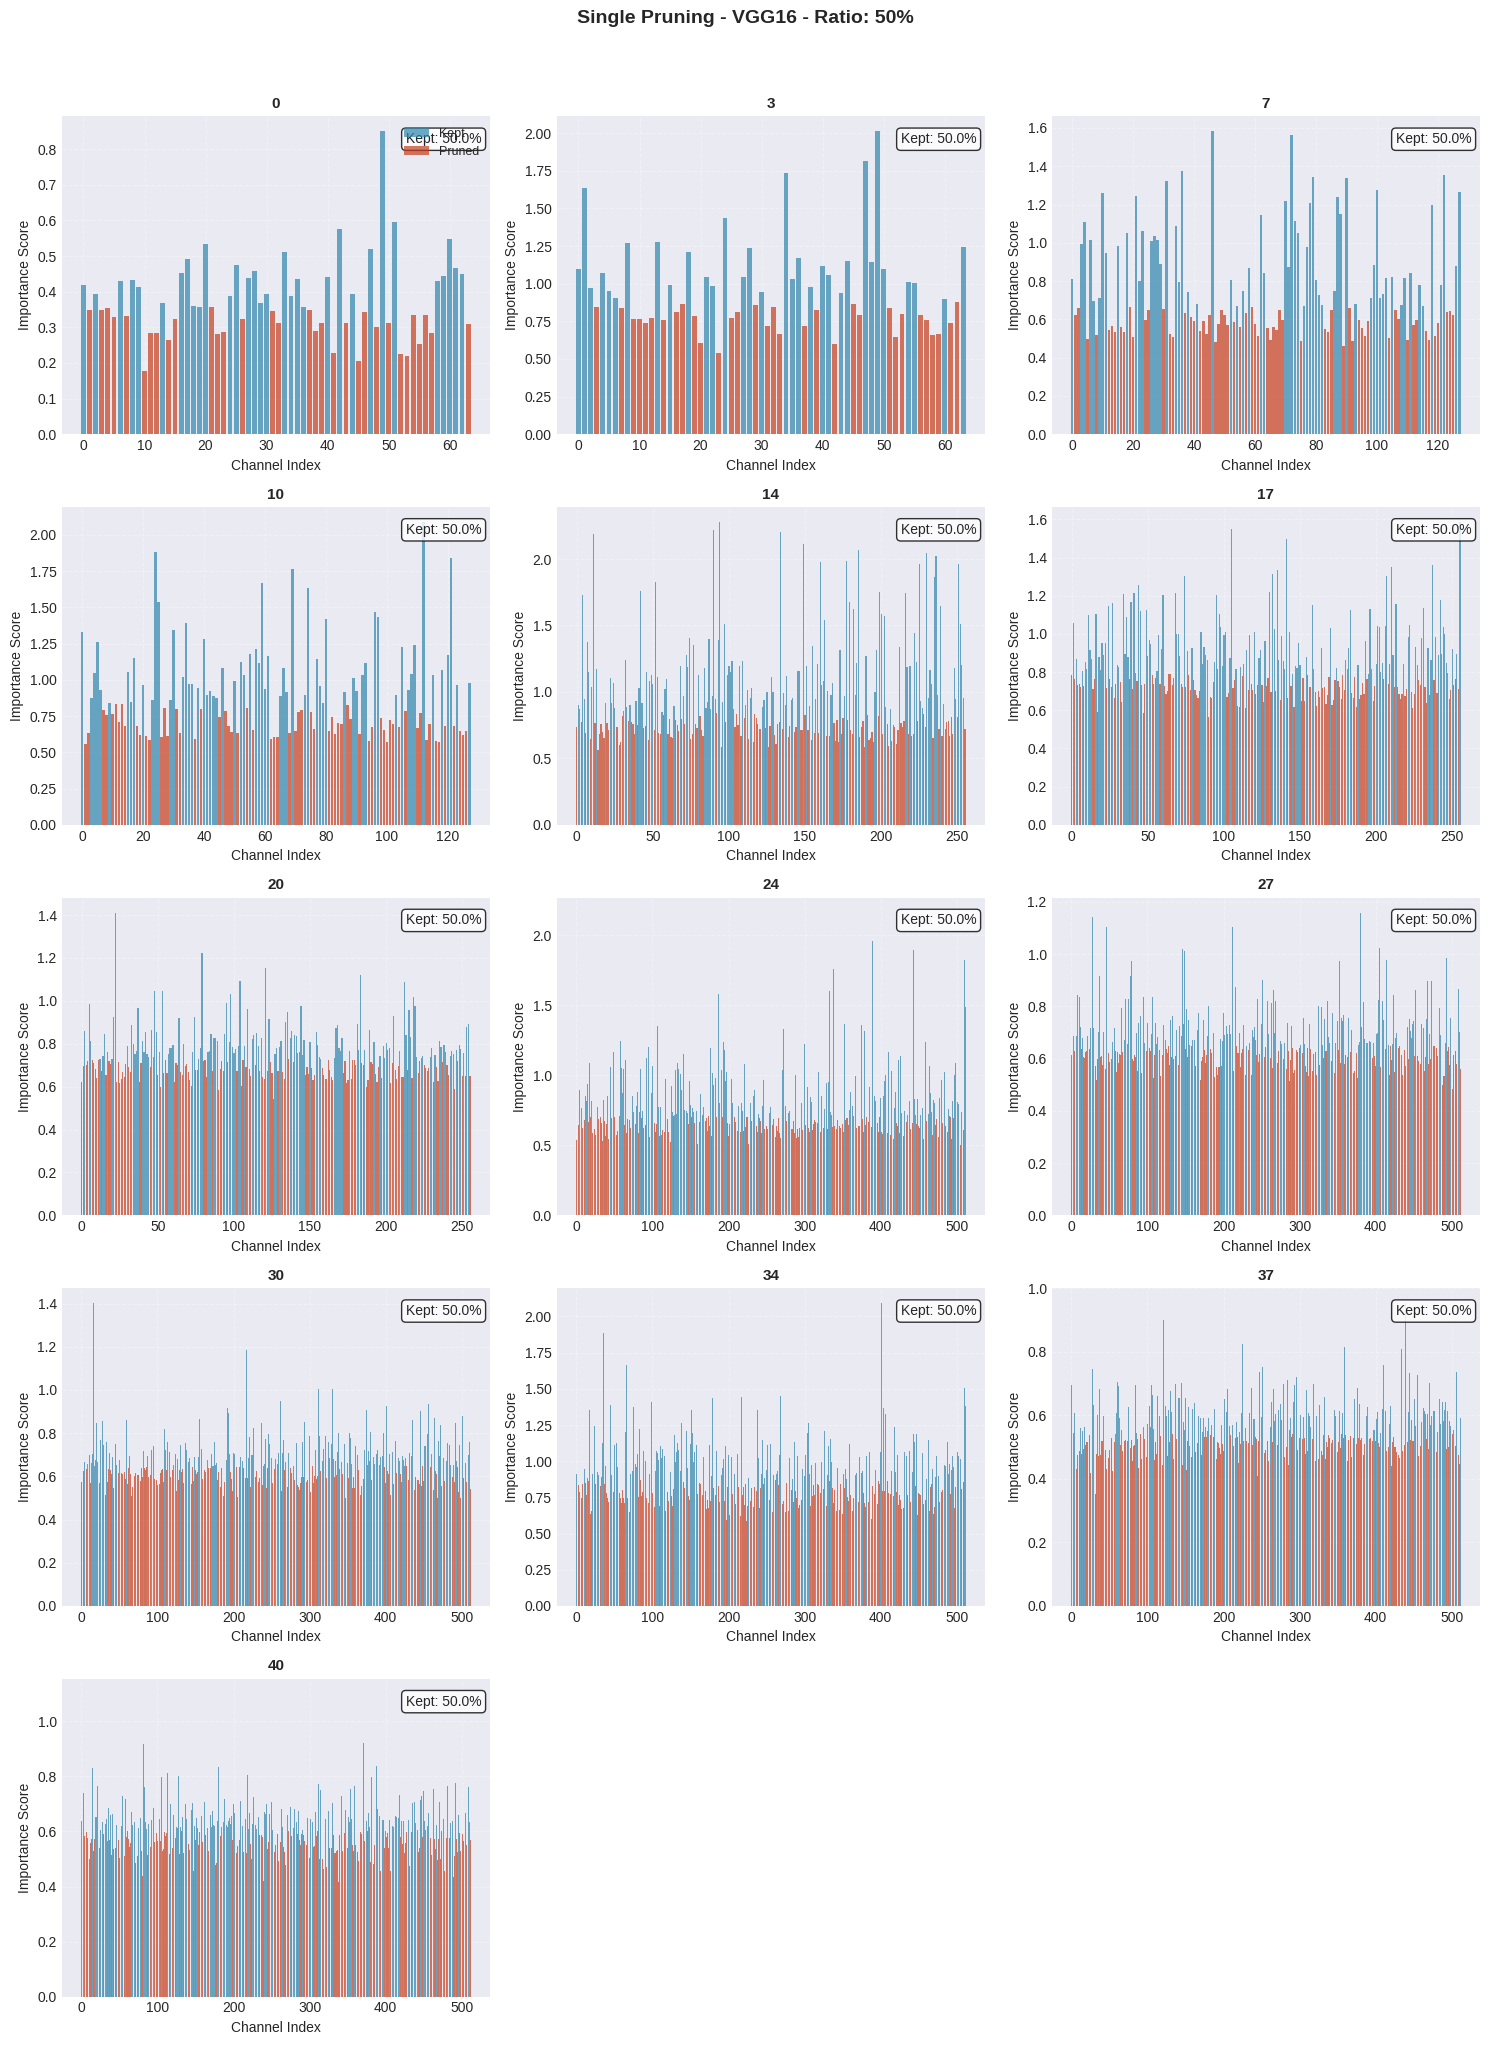

   No FT - Val: 10.00%


   With FT - Val: 80.42%


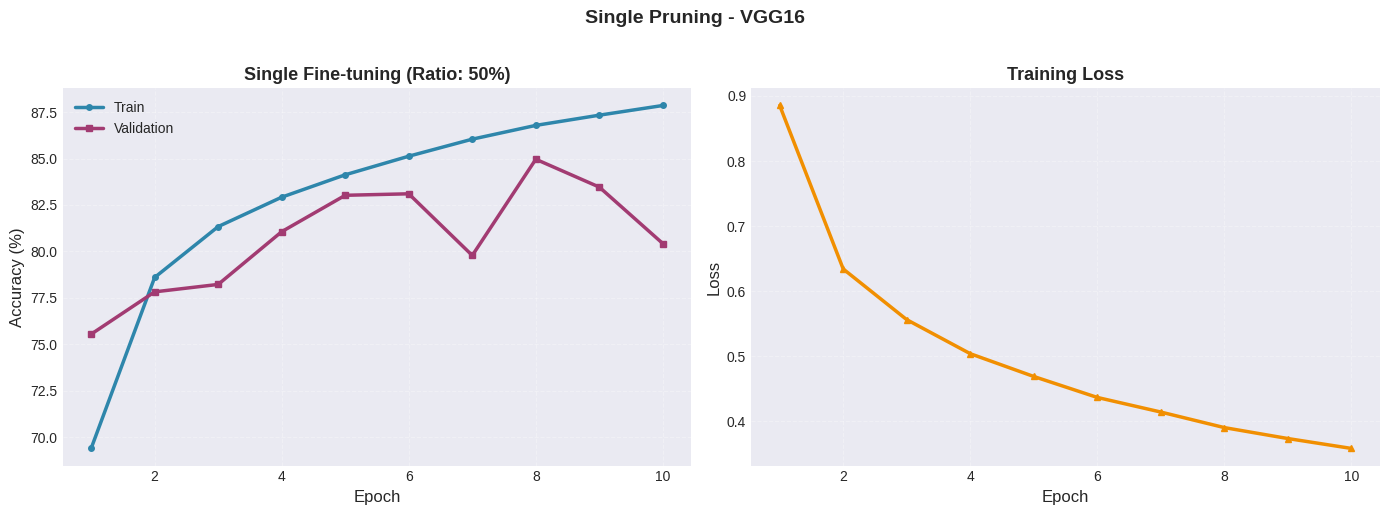

   ⭐ New best single model! Val Acc: 80.42%

──────────────────────────────────────────────────
📌 Testing ratio: 60%
──────────────────────────────────────────────────

📊 SINGLE MODEL Pruning - Ratio: 0.60


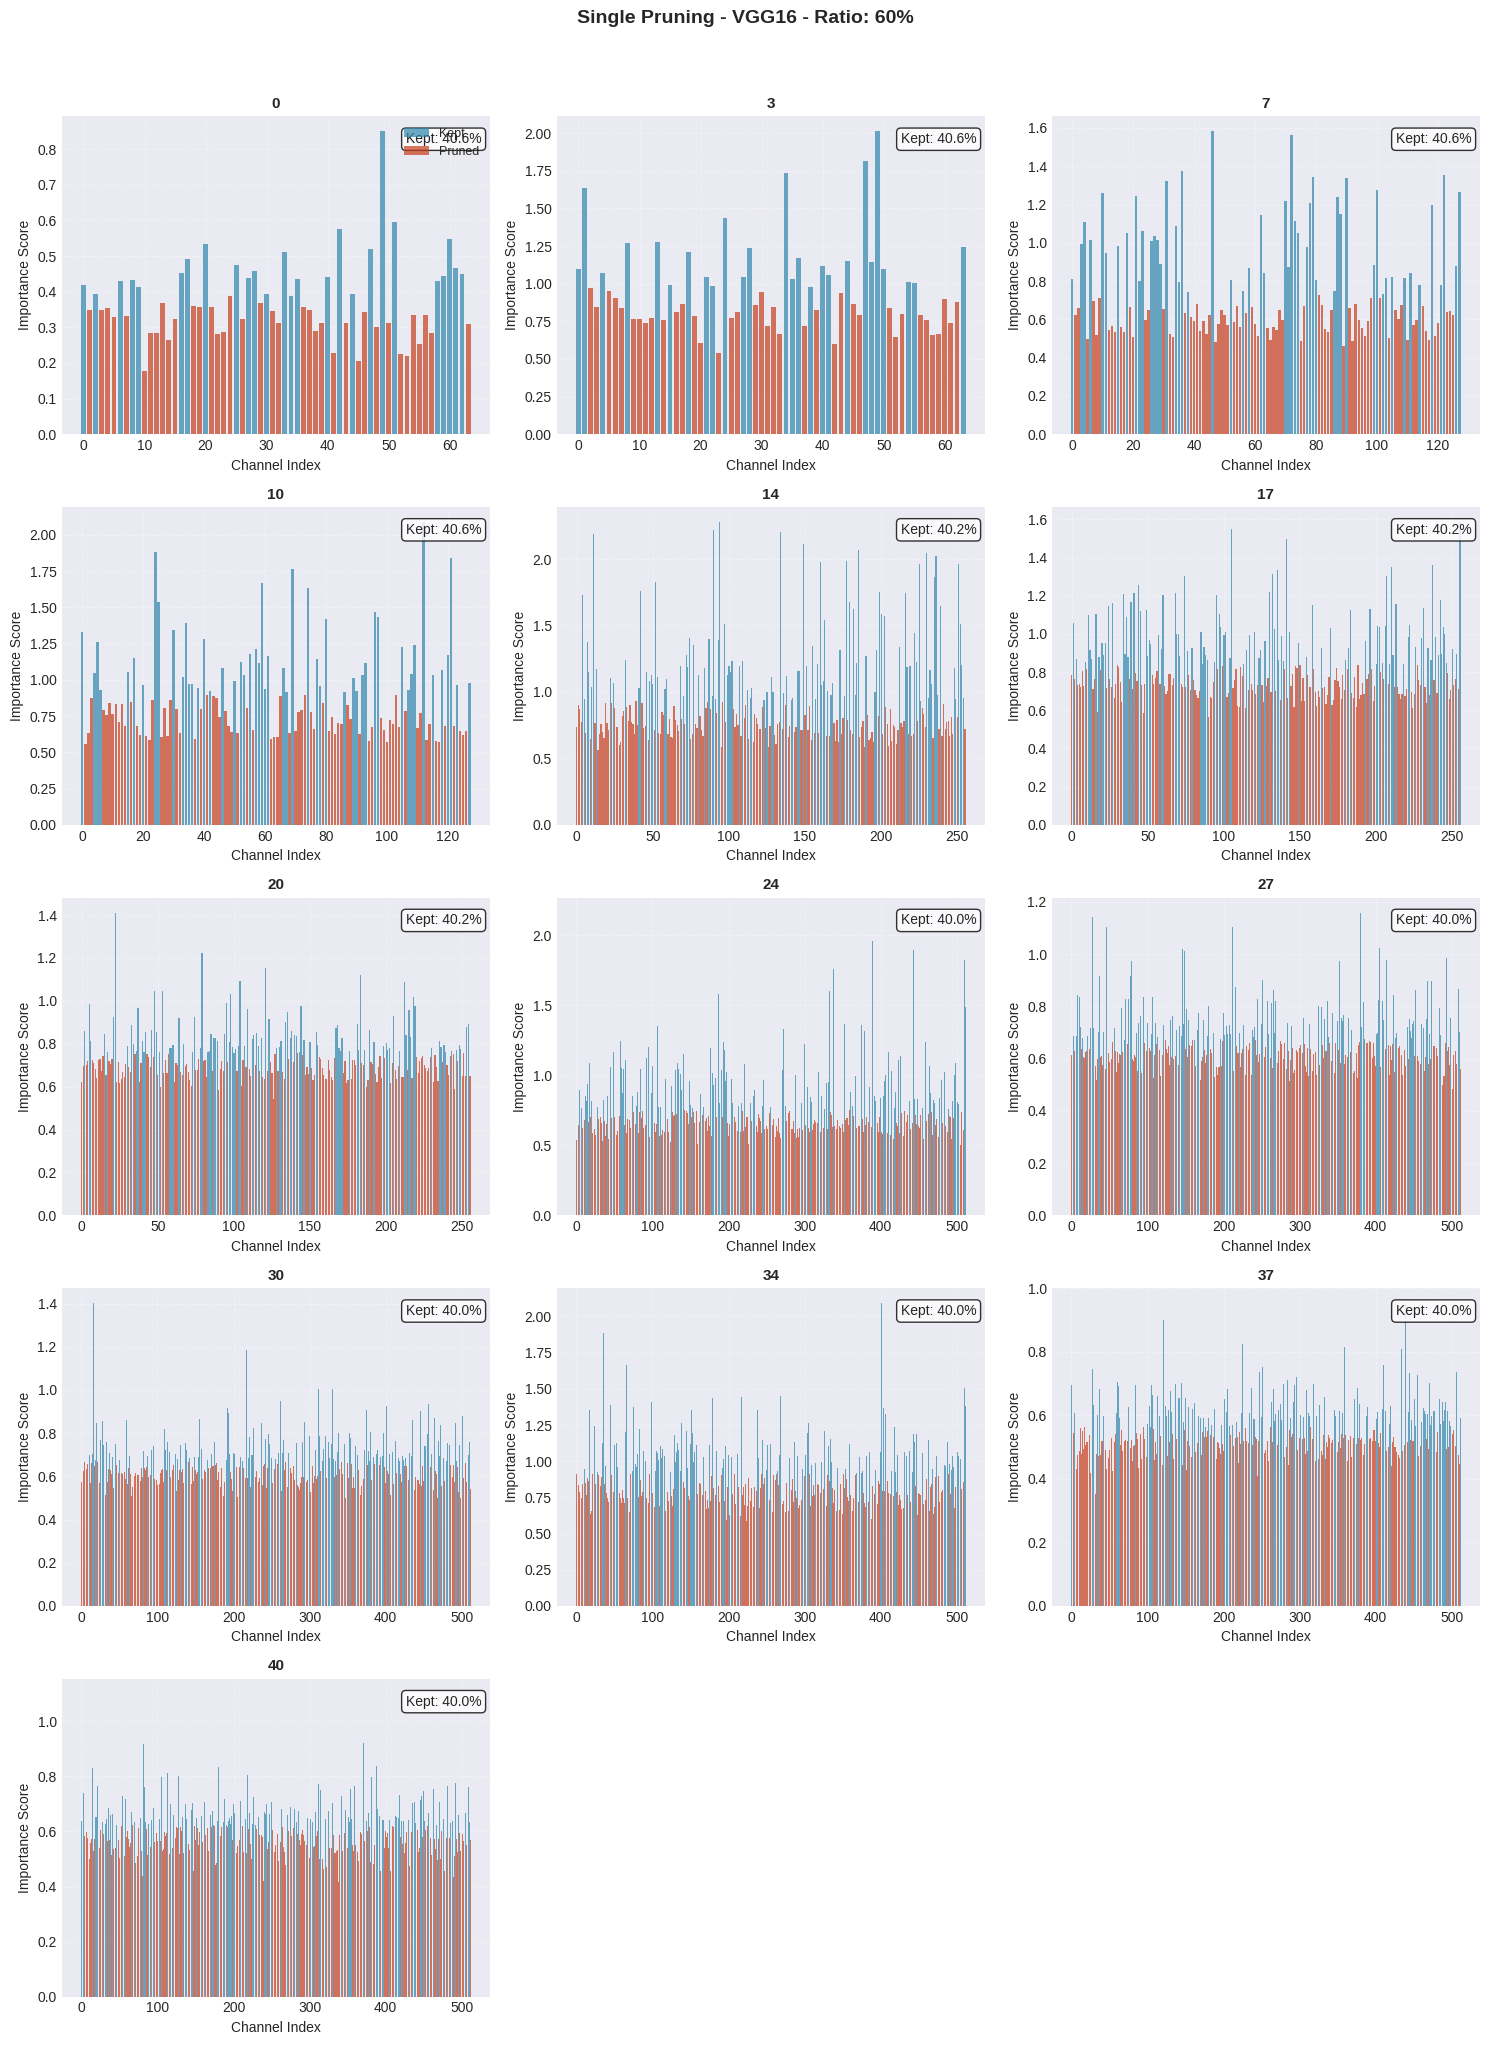

   No FT - Val: 10.00%


In [ ]:
def compute_flops(model, input_shape=(1,3,32,32)):
    model.eval()
    dummy = torch.randn(*input_shape).to(next(model.parameters()).device)
    flops, params = profile(model, inputs=(dummy,), verbose=False)
    return flops, params

# =========================
# Prune-Ratio Sweep with Proper Seeding Approach
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import numpy as np
from thop import clever_format

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B8F5E']

# Create results directory
Path("sweep_results").mkdir(exist_ok=True)

# Store results for both approaches
single_results = []      # Single model pruning
consensus_results = []    # Consensus-based pruning

# Track best configuration
best_single_val = 0
best_consensus_val = 0
best_single_config = None
best_consensus_config = None

# =========================
# Save/Load Functions for Sweep
# =========================
def get_model_path(config, suffix=""):
    """Generate save path for model"""
    os.makedirs(config['model_save_dir'], exist_ok=True)
    return os.path.join(config['model_save_dir'], f"{config['model']}_{config['dataset']}{suffix}.pth")

def save_model_sweep(model, config, suffix="", val_acc=None):
    """Save model with metadata including seed info - for sweep use"""
    path = get_model_path(config, suffix)

    # Extract seed index from suffix if present
    seed_idx = None
    if 'seed' in suffix:
        try:
            seed_idx = int(suffix.split('seed')[-1])
        except:
            pass

    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'timestamp': datetime.now().isoformat(),
        'seed_idx': seed_idx,
        'val_acc': val_acc,
        'model_type': config['model'],
        'dataset': config['dataset']
    }, path)
    print(f"✅ Model saved to {path} (seed {seed_idx}, val_acc: {val_acc:.2f}%)")

def load_model_if_exists_sweep(adapter, config, suffix=""):
    """Load model if it exists - for sweep use"""
    path = get_model_path(config, suffix)

    if os.path.exists(path) and not config['force_retrain']:
        try:
            print(f"📂 Found existing model at {path}")
            checkpoint = torch.load(path, map_location=device)

            # Verify model and dataset match
            if (checkpoint['config']['model'] == config['model'] and
                checkpoint['config']['dataset'] == config['dataset']):

                model = adapter.build(config['num_classes']).to(device)
                model.load_state_dict(checkpoint['model_state_dict'])

                # Print metadata
                timestamp = checkpoint.get('timestamp', 'unknown')
                val_acc = checkpoint.get('val_acc', 'unknown')
                seed_idx = checkpoint.get('seed_idx', 'unknown')

                print(f"✅ Loaded seed {seed_idx} from {timestamp}")
                if val_acc != 'unknown':
                    print(f"   Val Acc: {val_acc:.2f}%")

                return model, True
            else:
                print(f"⚠️ Saved model is for {checkpoint['config']['model']}/{checkpoint['config']['dataset']}, "
                      f"want {config['model']}/{config['dataset']}")
        except Exception as e:
            print(f"⚠️ Error loading model: {e}")

    return None, False

# =========================
# Seed Management Functions
# =========================
def get_available_seeds(config):
    """Get list of available seed indices for current model/dataset"""
    seed_dir = config['model_save_dir']
    os.makedirs(seed_dir, exist_ok=True)

    available = []
    pattern = f"{config['model']}_{config['dataset']}_seed"

    for f in os.listdir(seed_dir):
        if f.startswith(pattern) and f.endswith('.pth'):
            try:
                seed_str = f.replace(pattern, '').replace('.pth', '')
                seed_idx = int(seed_str)
                available.append(seed_idx)
            except:
                continue

    return sorted(available)

def get_required_seeds(config, num_needed):
    """
    Determine which seeds to use based on availability
    Returns: (seeds_to_use, seeds_to_train)
    """
    available = get_available_seeds(config)

    print(f"\n📚 Seed Management:")
    print(f"   - Requested: {num_needed} seeds")
    print(f"   - Available in drive: {len(available)} seeds {available}")

    if len(available) >= num_needed:
        # Case 1: Enough seeds available - randomly select
        seeds_to_use = sorted(random.sample(available, num_needed))
        seeds_to_train = []
        print(f"   - Using {num_needed} existing seeds: {seeds_to_use}")
        print(f"   - No new seeds needed")
    else:
        # Case 2: Need more seeds - use all available + train new ones
        num_to_train = num_needed - len(available)
        next_idx = max(available) + 1 if available else 0
        new_seeds = list(range(next_idx, next_idx + num_to_train))

        seeds_to_use = available + new_seeds
        seeds_to_train = new_seeds

        print(f"   - Using all {len(available)} existing seeds: {available}")
        print(f"   - Training {num_to_train} new seeds: {new_seeds}")

    return seeds_to_use, seeds_to_train

# =========================
# Enhanced Seed Training for Sweep
# =========================
def load_or_train_seeds_for_sweep(adapter, config, train_loader, val_loader):
    """
    Load or train seeds based on availability - only trains missing seeds
    Returns: list of score dicts, list of seed indices used, list of trained seeds
    """
    num_needed = config['num_consensus_seeds']
    seeds_to_use, seeds_to_train = get_required_seeds(config, num_needed)

    all_scores = []
    models = []
    base_seed = config.get('seed', 42)

    for seed_idx in seeds_to_use:
        suffix = f"_seed{seed_idx}"
        current_seed = base_seed + seed_idx * 100

        print(f"\n   {'📂 Loading' if seed_idx not in seeds_to_train else '🌱 Training'} Seed {seed_idx}")

        # Set seed for reproducibility
        torch.manual_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        if seed_idx not in seeds_to_train:
            # Load existing model
            model, loaded = load_model_if_exists_sweep(adapter, config, suffix=suffix)
            if not loaded:
                raise RuntimeError(f"Seed {seed_idx} claimed available but couldn't be loaded!")
        else:
            # Train new model
            model = adapter.build(config['num_classes']).to(device)
            opt, sch, E = adapter.training_recipe(model)

            # Train for fewer epochs in sweep for speed
            train_epochs = min(E, 5)
            for e in range(train_epochs):
                tr_acc, tr_loss = train_epoch(model, train_loader, opt, nn.CrossEntropyLoss())
                val_acc = evaluate(model, val_loader)
                if sch: sch.step()
                if (e+1) % 5 == 0:
                    print(f"      Epoch {e+1}/{train_epochs}: Val Acc {val_acc:.2f}%")

            # Save the trained model
            if config['save_model']:
                val_acc = evaluate(model, val_loader)
                save_model_sweep(model, config, suffix=suffix, val_acc=val_acc)

        # Collect scores (always do this, whether loaded or trained)
        collector = ActivationCollector()
        layers = adapter.prunable_layers(model)
        collector.register_hooks(model, layers)

        model.eval()
        with torch.no_grad():
            for x,_ in val_loader:
                _ = model(x.to(device))

        collector.remove_hooks()

        if config['score_type'] in ['nisp', 'taylor_expansion']:
            if config['score_type'] == 'nisp':
                scores = compute_nisp_scores(model, val_loader, layers, device)
            else:
                scores = compute_taylor_scores(model, val_loader, layers, device)
        else:
            scores = collector.compute_scores(config['score_type'])

        all_scores.append(scores)
        models.append(model)

    return all_scores, models, seeds_to_use, seeds_to_train

# =========================
# Mask Builder (for single model)
# =========================
def build_masks_from_scores(scores, prune_ratio, method="local"):
    masks = {}

    if method == "local":
        for lname, s in scores.items():
            C = s.numel()
            k = int(prune_ratio * C)
            idx = torch.argsort(s)
            keep = torch.ones(C, dtype=torch.bool)
            if k > 0:
                keep[idx[:k]] = False
            masks[lname] = keep
    else:  # global
        all_ch = []
        for lname, s in scores.items():
            for i in range(s.numel()):
                all_ch.append((lname, i, s[i].item()))
        all_ch.sort(key=lambda x: x[2])

        total = len(all_ch)
        k = int(prune_ratio * total)
        masks = {lname: torch.ones(scores[lname].numel(), dtype=torch.bool) for lname in scores}

        for n in range(k):
            lname, i, _ = all_ch[n]
            masks[lname][i] = False

    return masks

# =========================
# Consensus Mask Builder - WITH SAME PRUNE RATIO
# =========================
def build_consensus_masks_with_ratio(all_scores, config, target_ratio):
    """Build masks that respect target ratio using importance * agreement"""

    num_seeds = len(all_scores)
    layer_names = all_scores[0].keys()
    consensus_masks = {}

    percentile = config['consensus_percentile']

    print(f"\n🔍 Building consensus masks for target ratio {target_ratio:.0%}:")
    print(f"   - Unimportant candidate = bottom {percentile}% within each seed")

    total_pruned = 0
    total_channels = 0

    for layer in layer_names:
        layer_scores = torch.stack([scores[layer] for scores in all_scores])

        # 1. Average importance (higher = more unimportant)
        avg_importance = layer_scores.mean(dim=0)

        # 2. Agreement score
        agreement = torch.zeros(layer_scores.shape[1])
        threshold_idx = max(1, int(len(layer_scores[0]) * (percentile / 100)))

        for seed_idx in range(num_seeds):
            seed_scores = layer_scores[seed_idx]
            _, unimportant = torch.topk(seed_scores, threshold_idx, largest=False)
            agreement[unimportant] += 1
        agreement = agreement / num_seeds

        # 3. Combined score: importance * agreement
        # Higher = more prune-worthy (unimportant AND high agreement)
        combined = avg_importance * agreement

        # 4. Select top k
        k = int(target_ratio * len(combined))
        if k > 0:
            _, prune_indices = torch.topk(combined, k, largest=True)
        else:
            prune_indices = []

        # Create mask
        mask = torch.ones(len(combined), dtype=torch.bool)
        if len(prune_indices) > 0:
            mask[prune_indices] = False
        consensus_masks[layer] = mask

        layer_pruned = len(prune_indices)
        layer_total = len(mask)
        total_pruned += layer_pruned
        total_channels += layer_total

        print(f"   Layer {layer}: pruning {layer_pruned}/{layer_total} channels ({layer_pruned/layer_total*100:.1f}%)")

    overall_ratio = total_pruned / total_channels if total_channels > 0 else 0
    print(f"\n📊 Consensus pruning overall: {total_pruned}/{total_channels} channels ({overall_ratio*100:.1f}%)")
    print(f"   Target ratio: {target_ratio:.0%} | Achieved: {overall_ratio:.1%}")

    return consensus_masks

# =========================
# Experiment Runner - Single Model (Standard)
# =========================
def run_single_experiment(prune_ratio, save_visualizations=True):
    """Run single model pruning experiment with given ratio - validation only during sweep"""

    original_ratio = config["prune_ratio"]
    config["prune_ratio"] = prune_ratio

    print(f"\n{'='*60}")
    print(f"📊 SINGLE MODEL Pruning - Ratio: {prune_ratio:.2f}")
    print(f"{'='*60}")

    # Apply pruning
    pruned = adapter.prune(baseline_model, scores, config).to(device)

    # Visualize masks
    if save_visualizations:
        masks = build_masks_from_scores(scores, prune_ratio, config['prune_scope'])
        visualize_pruning_masks(scores, masks, prune_ratio, config, mode="Single")

    # BN recalibration
    if config["bn_recalibration_batches"] > 0:
        pruned.train()
        with torch.no_grad():
            for i, (x, _) in enumerate(train_loader):
                if i >= config["bn_recalibration_batches"]: break
                _ = pruned(x.to(device))

    # Evaluate without fine-tuning (validation only)
    acc_no_ft_val = evaluate(pruned, val_loader)
    print(f"   No FT - Val: {acc_no_ft_val:.2f}%")

    # Fine-tune with tracking
    opt_ft = torch.optim.SGD(pruned.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    sched_ft = torch.optim.lr_scheduler.StepLR(opt_ft, step_size=10, gamma=0.1)

    ft_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'epochs': []}

    for e in range(config["finetune_epochs"]):
        tr_acc, tr_loss = train_epoch(pruned, train_loader, opt_ft, criterion)
        val_acc = evaluate(pruned, val_loader)
        sched_ft.step()

        ft_history['train_acc'].append(tr_acc)
        ft_history['val_acc'].append(val_acc)
        ft_history['train_loss'].append(tr_loss)
        ft_history['epochs'].append(e+1)

    acc_ft_val = val_acc
    print(f"   With FT - Val: {acc_ft_val:.2f}%")

    # Compute metrics
    base_flops, base_params = compute_flops(baseline_model)
    prun_flops, prun_params = compute_flops(pruned)

    flops_reduction = 100.0 * (1.0 - prun_flops / base_flops) if base_flops > 0 else 0
    param_reduction = 100.0 * (1.0 - prun_params / base_params) if base_params > 0 else 0

    # Plot fine-tuning history
    if save_visualizations:
        plot_finetuning_history(ft_history, prune_ratio, config, mode="Single")

    config["prune_ratio"] = original_ratio

    return {
        "ratio": prune_ratio,
        "acc_no_ft_val": acc_no_ft_val,
        "acc_ft_val": acc_ft_val,
        "params": int(prun_params),
        "flops": int(prun_flops),
        "param_reduction_%": param_reduction,
        "flops_reduction_%": flops_reduction,
        "ft_history": ft_history,
        "model": pruned  # Store for potential best model selection
    }

# =========================
# Experiment Runner - Consensus Model (with seed management)
# =========================
def run_consensus_experiment(prune_ratio, save_visualizations=True):
    """Run consensus pruning experiment with same ratio as single model - uses seed management"""

    print(f"\n{'='*60}")
    print(f"🔬 CONSENSUS Pruning - Ratio: {prune_ratio:.2f}")
    print(f"{'='*60}")

    # Load or train seeds using our smart seed management
    all_scores, seed_models, seeds_used, seeds_trained = load_or_train_seeds_for_sweep(
        adapter, config, train_loader, val_loader
    )

    # Build consensus masks that achieve target ratio
    consensus_masks = build_consensus_masks_with_ratio(all_scores, config, prune_ratio)

    # Use first model as baseline for pruning
    baseline_consensus = copy.deepcopy(baseline_model)

    # Apply pruning with consensus masks
    original_build_masks = adapter._build_masks
    adapter._build_masks = lambda s, c: consensus_masks

    # Temporarily set prune_ratio to ensure adapter works
    original_prune_ratio = config["prune_ratio"]
    config["prune_ratio"] = prune_ratio

    pruned = adapter.prune(baseline_consensus, scores, config).to(device)

    # Restore original values
    config["prune_ratio"] = original_prune_ratio
    adapter._build_masks = original_build_masks

    # Visualize masks
    if save_visualizations:
        visualize_pruning_masks(scores, consensus_masks, prune_ratio, config, mode="Consensus")

    # BN recalibration
    if config["bn_recalibration_batches"] > 0:
        pruned.train()
        with torch.no_grad():
            for i, (x, _) in enumerate(train_loader):
                if i >= config["bn_recalibration_batches"]: break
                _ = pruned(x.to(device))

    # Evaluate without fine-tuning (validation only)
    acc_no_ft_val = evaluate(pruned, val_loader)
    print(f"   No FT - Val: {acc_no_ft_val:.2f}%")

    # Fine-tune with tracking
    opt_ft = torch.optim.SGD(pruned.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

    ft_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'epochs': []}

    for e in range(config["finetune_epochs"]):
        tr_acc, tr_loss = train_epoch(pruned, train_loader, opt_ft, criterion)
        val_acc = evaluate(pruned, val_loader)

        ft_history['train_acc'].append(tr_acc)
        ft_history['val_acc'].append(val_acc)
        ft_history['train_loss'].append(tr_loss)
        ft_history['epochs'].append(e+1)

    acc_ft_val = val_acc
    print(f"   With FT - Val: {acc_ft_val:.2f}%")

    # Compute metrics
    base_params = count_params(baseline_model)
    prun_params = count_params(pruned)
    param_reduction = 100.0 * (1.0 - prun_params / base_params)

    # Plot fine-tuning history
    if save_visualizations:
        plot_finetuning_history(ft_history, prune_ratio, config, mode="Consensus")

    # Add seed info to results
    return {
        "ratio": prune_ratio,
        "acc_no_ft_val": acc_no_ft_val,
        "acc_ft_val": acc_ft_val,
        "params": int(prun_params),
        "param_reduction_%": param_reduction,
        "ft_history": ft_history,
        "model": pruned,
        "seeds_used": seeds_used,
        "seeds_trained": seeds_trained,
        "num_seeds_loaded": len([s for s in seeds_used if s not in seeds_trained]),
        "num_seeds_trained": len(seeds_trained)
    }

# =========================
# Visualization Functions
# =========================
def visualize_pruning_masks(scores, masks, value, config, mode="Single"):
    """Visualize which channels are pruned per layer"""

    n_layers = len(scores)
    n_cols = min(3, n_layers)
    n_rows = (n_layers + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    if n_layers == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, (layer_name, score) in enumerate(scores.items()):
        if idx >= len(axes):
            break

        ax = axes[idx]

        # Get mask for this layer
        mask = masks.get(layer_name, torch.ones_like(score, dtype=torch.bool))

        # Create visualization data
        channels = np.arange(len(score))
        importance = score.numpy()
        pruned = ~mask.numpy()

        # Plot
        ax.bar(channels[~pruned], importance[~pruned],
               color=COLORS[0], alpha=0.7, label='Kept', width=0.8)
        ax.bar(channels[pruned], importance[pruned],
               color=COLORS[3], alpha=0.7, label='Pruned', width=0.8)

        kept_pct = 100 * (1 - sum(pruned)/len(pruned))
        ax.text(0.98, 0.95, f'Kept: {kept_pct:.1f}%',
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        ax.set_xlabel('Channel Index', fontsize=10)
        ax.set_ylabel('Importance Score', fontsize=10)

        short_name = layer_name.replace('features.', '').replace('classifier.', '')
        if len(short_name) > 20:
            short_name = short_name[:20] + '...'
        ax.set_title(f'{short_name}', fontsize=11, fontweight='bold')

        if idx == 0:
            ax.legend(loc='upper right', fontsize=9)

        ax.grid(True, alpha=0.3, linestyle='--')

    # Hide empty subplots
    for idx in range(len(scores), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f'{mode} Pruning - {config["model"].upper()} - Ratio: {value:.0%}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'sweep_results/masks_{mode.lower()}_{config["model"]}_{int(value*100)}.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

def plot_finetuning_history(history, value, config, mode="Single"):
    """Plot fine-tuning progress"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = history['epochs']

    # Accuracy plot
    ax1.plot(epochs, history['train_acc'], color=COLORS[0], linewidth=2.5,
             marker='o', markersize=4, label='Train')
    ax1.plot(epochs, history['val_acc'], color=COLORS[1], linewidth=2.5,
             marker='s', markersize=4, label='Validation')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy (%)', fontsize=12)
    ax1.set_title(f'{mode} Fine-tuning (Ratio: {value:.0%})', fontsize=13, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')

    # Loss plot
    ax2.plot(epochs, history['train_loss'], color=COLORS[2], linewidth=2.5,
             marker='^', markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Training Loss', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')

    plt.suptitle(f'{mode} Pruning - {config["model"].upper()}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'sweep_results/fthistory_{mode.lower()}_{config["model"]}_{int(value*100)}.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

def plot_comparison_results(single_results, consensus_results, config, baseline_val, base_params):
    """Plot comparison between single and consensus approaches using validation metrics"""

    fig = plt.figure(figsize=(18, 10))

    df_single = pd.DataFrame(single_results)
    df_consensus = pd.DataFrame(consensus_results)

    # 1. Accuracy Comparison
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(df_single['ratio'], df_single['acc_ft_val'], 'o-', color=COLORS[0],
             linewidth=2.5, markersize=8, label='Single Model')
    ax1.plot(df_consensus['ratio'], df_consensus['acc_ft_val'], 's-', color=COLORS[1],
             linewidth=2.5, markersize=8, label='Consensus')
    ax1.axhline(y=baseline_val, color='gray', linestyle='--', alpha=0.7, label=f'Baseline: {baseline_val:.1f}%')
    ax1.set_xlabel('Prune Ratio')
    ax1.set_ylabel('Validation Accuracy (%)')
    ax1.set_title('Accuracy Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Compression Comparison
    ax2 = plt.subplot(2, 3, 2)
    x = np.arange(len(df_single))
    width = 0.35

    bars1 = ax2.bar(x - width/2, df_single['param_reduction_%'], width,
                    label='Single', color=COLORS[0], alpha=0.8)
    bars2 = ax2.bar(x + width/2, df_consensus['param_reduction_%'], width,
                    label='Consensus', color=COLORS[1], alpha=0.8)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

    ax2.set_xlabel('Prune Ratio')
    ax2.set_ylabel('Parameter Reduction (%)')
    ax2.set_title('Compression Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'{r:.0%}' for r in df_single['ratio']])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # 3. Accuracy Drop
    ax3 = plt.subplot(2, 3, 3)
    single_drop = baseline_val - df_single['acc_ft_val']
    consensus_drop = baseline_val - df_consensus['acc_ft_val']

    ax3.plot(df_single['ratio'], single_drop, 'o-', color=COLORS[0], label='Single')
    ax3.plot(df_consensus['ratio'], consensus_drop, 's-', color=COLORS[1], label='Consensus')
    ax3.set_xlabel('Prune Ratio')
    ax3.set_ylabel('Accuracy Drop (pp)')
    ax3.set_title('Accuracy Drop Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Efficiency Frontier
    ax4 = plt.subplot(2, 3, 4)
    ax4.plot([base_params/1e6], [baseline_val], 'r*', markersize=15, label='Baseline')
    ax4.plot(df_single['params']/1e6, df_single['acc_ft_val'], 'o-', color=COLORS[0],
             linewidth=2, markersize=8, label='Single')
    ax4.plot(df_consensus['params']/1e6, df_consensus['acc_ft_val'], 's-', color=COLORS[1],
             linewidth=2, markersize=8, label='Consensus')

    for i, row in df_single.iterrows():
        ax4.annotate(f"{row['ratio']:.0%}", (row['params']/1e6, row['acc_ft_val']), fontsize=8)

    ax4.set_xlabel('Parameters (Millions)')
    ax4.set_ylabel('Validation Accuracy (%)')
    ax4.set_title('Efficiency Frontier')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # 5. Improvement of Consensus over Single
    ax5 = plt.subplot(2, 3, 5)
    improvement = df_consensus['acc_ft_val'] - df_single['acc_ft_val']
    colors = [COLORS[2] if imp > 0 else COLORS[3] for imp in improvement]
    bars = ax5.bar([f'{r:.0%}' for r in df_single['ratio']], improvement, color=colors, alpha=0.8)

    for bar, imp in zip(bars, improvement):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + (0.1 if imp > 0 else -0.3),
                f'{imp:+.2f}pp', ha='center', va='bottom' if imp > 0 else 'top', fontsize=9)

    ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax5.set_xlabel('Prune Ratio')
    ax5.set_ylabel('Accuracy Improvement (pp)')
    ax5.set_title('Consensus vs Single Improvement')
    ax5.grid(True, alpha=0.3, axis='y')

    # 6. Summary Table
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('tight')
    ax6.axis('off')

    table_data = []
    for i in range(len(df_single)):
        # Add seed info to table if available
        seeds_loaded = df_consensus.iloc[i].get('num_seeds_loaded', 'N/A')
        seeds_trained = df_consensus.iloc[i].get('num_seeds_trained', 'N/A')

        table_data.append([
            f"{df_single.iloc[i]['ratio']:.0%}",
            f"{df_single.iloc[i]['acc_ft_val']:.2f}%",
            f"{df_single.iloc[i]['param_reduction_%']:.1f}%",
            f"{df_consensus.iloc[i]['acc_ft_val']:.2f}%",
            f"{df_consensus.iloc[i]['param_reduction_%']:.1f}%",
            f"{improvement.iloc[i]:+.2f}pp",
            f"{seeds_loaded}/{seeds_trained}" if seeds_loaded != 'N/A' else 'N/A'
        ])

    col_labels = ['Ratio', 'Single Acc', 'Single Comp', 'Consensus Acc', 'Consensus Comp', 'Improv', 'Load/Train']
    col_widths = [0.08, 0.12, 0.12, 0.12, 0.12, 0.08, 0.1]

    table = ax6.table(cellText=table_data,
                      colLabels=col_labels,
                      cellLoc='center',
                      loc='center',
                      colWidths=col_widths)

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.2, 1.5)

    # Color header
    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_facecolor('#2C3E50')
            cell.set_text_props(color='white', weight='bold')

    plt.suptitle(f'Pruning Approach Comparison - {config["model"].upper()}',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'sweep_results/comparison_{config["model"]}.png', dpi=150, bbox_inches='tight')
    plt.show()

# =========================
# FINAL TEST EVALUATION
# =========================
def final_test_evaluation(model, name="Model"):
    """One-time final evaluation on test set"""
    print(f"\n🎯 Final Test Evaluation - {name}")
    test_acc = evaluate(model, test_loader)
    print(f"   Test Accuracy: {test_acc:.2f}%")
    return test_acc

# =========================
# Run Sweeps
# =========================
print("\n" + "="*80)
print("🚀 STARTING PRUNING SWEEP EXPERIMENTS")
print("="*80)
print("⚠️  Test set is LOCKED - will only be used at the very end")

# Get baseline metrics (validation only)
baseline_val = evaluate(baseline_model, val_loader)
base_params = count_params(baseline_model)

print(f"\n📈 Baseline Validation Accuracy: {baseline_val:.2f}%")
print(f"📊 Baseline Parameters: {base_params/1e6:.2f}M")
print(f"🔒 Test set untouched: {len(test_loader.dataset)} samples reserved for final evaluation")

# Define prune ratios to test (same for both approaches)
prune_ratios = [0.50, 0.60]

# 1. SINGLE MODEL SWEEP
print("\n" + "="*80)
print("📊 SINGLE MODEL PRUNING SWEEP")
print("="*80)

for ratio in prune_ratios:
    print(f"\n{'─'*50}")
    print(f"📌 Testing ratio: {ratio:.0%}")
    print(f"{'─'*50}")

    res = run_single_experiment(ratio, save_visualizations=True)
    single_results.append(res)

    # Track best model based on validation accuracy
    if res['acc_ft_val'] > best_single_val:
        best_single_val = res['acc_ft_val']
        best_single_config = {
            'ratio': ratio,
            'model': res['model'],
            'val_acc': res['acc_ft_val'],
            'params': res['params']
        }
        print(f"   ⭐ New best single model! Val Acc: {best_single_val:.2f}%")

    # Save intermediate
    pd.DataFrame(single_results).to_csv(f'sweep_results/single_intermediate.csv', index=False)

# 2. CONSENSUS SWEEP - Same ratios (with seed management)
print("\n" + "="*80)
print("🔬 CONSENSUS PRUNING SWEEP (with seed management)")
print("="*80)

for ratio in prune_ratios:
    print(f"\n{'─'*50}")
    print(f"📌 Testing ratio: {ratio:.0%} with consensus")
    print(f"{'─'*50}")

    res = run_consensus_experiment(ratio, save_visualizations=True)
    consensus_results.append(res)

    # Print seed usage summary for this experiment
    if 'seeds_used' in res:
        print(f"\n   📊 Seed Usage for ratio {ratio:.0%}:")
        print(f"      - Seeds used: {res['seeds_used']}")
        print(f"      - Loaded from cache: {res['num_seeds_loaded']}")
        print(f"      - Newly trained: {res['num_seeds_trained']}")

    # Track best model based on validation accuracy
    if res['acc_ft_val'] > best_consensus_val:
        best_consensus_val = res['acc_ft_val']
        best_consensus_config = {
            'ratio': ratio,
            'model': res['model'],
            'val_acc': res['acc_ft_val'],
            'params': res['params']
        }
        print(f"   ⭐ New best consensus model! Val Acc: {best_consensus_val:.2f}%")

    # Save intermediate
    pd.DataFrame(consensus_results).to_csv(f'sweep_results/consensus_intermediate.csv', index=False)

# 3. Plot Comparison
print("\n" + "="*80)
print("📊 GENERATING COMPARISON PLOTS")
print("="*80)

plot_comparison_results(single_results, consensus_results, config, baseline_val, base_params)

# 4. FINAL TEST EVALUATION - ONCE AT THE END
print("\n" + "="*80)
print("🎯 FINAL TEST EVALUATION")
print("="*80)

# Evaluate best models on test set
if best_single_config:
    single_test = final_test_evaluation(best_single_config['model'], "Best Single Model")
else:
    single_test = None

if best_consensus_config:
    consensus_test = final_test_evaluation(best_consensus_config['model'], "Best Consensus Model")
else:
    consensus_test = None

# 5. Save final results
df_single = pd.DataFrame(single_results)
df_consensus = pd.DataFrame(consensus_results)

df_single.to_csv(f'sweep_results/single_final_{config["model"]}.csv', index=False)
df_consensus.to_csv(f'sweep_results/consensus_final_{config["model"]}.csv', index=False)

# 6. Final Summary
print("\n" + "="*80)
print("📊 FINAL SWEEP SUMMARY")
print("="*80)
print(f"Model: {config['model']}")
print(f"Dataset: {config['dataset']}")
print(f"Baseline Validation Accuracy: {baseline_val:.2f}%")
print(f"Baseline Parameters: {base_params/1e6:.2f}M")
print("\nBest Configurations:")

if best_single_config:
    print(f"\n🏆 Best Single Model:")
    print(f"   Ratio: {best_single_config['ratio']:.0%}")
    print(f"   Validation Accuracy: {best_single_config['val_acc']:.2f}%")
    print(f"   Test Accuracy: {single_test:.2f}%")
    print(f"   Parameters: {best_single_config['params']/1e6:.2f}M")
    print(f"   Compression: {100*(1 - best_single_config['params']/base_params):.1f}%")

if best_consensus_config:
    print(f"\n🏆 Best Consensus Model:")
    print(f"   Ratio: {best_consensus_config['ratio']:.0%}")
    print(f"   Validation Accuracy: {best_consensus_config['val_acc']:.2f}%")
    print(f"   Test Accuracy: {consensus_test:.2f}%")
    print(f"   Parameters: {best_consensus_config['params']/1e6:.2f}M")
    print(f"   Compression: {100*(1 - best_consensus_config['params']/base_params):.1f}%")

# Print seed management summary for the sweep
print("\n📚 SEED MANAGEMENT SUMMARY:")
total_seeds_requested = len(prune_ratios) * config['num_consensus_seeds']
total_seeds_loaded = sum(r.get('num_seeds_loaded', 0) for r in consensus_results)
total_seeds_trained = sum(r.get('num_seeds_trained', 0) for r in consensus_results)
print(f"   Total seeds needed across all experiments: {total_seeds_requested}")
print(f"   Seeds loaded from cache: {total_seeds_loaded}")
print(f"   Seeds newly trained: {total_seeds_trained}")
if total_seeds_loaded > 0:
    print(f"   💰 GPU hours saved: ~{total_seeds_loaded * 5} minutes")  # Rough estimate

if best_single_config and best_consensus_config:
    print(f"\n📊 Comparison:")
    print(f"   Test Accuracy Difference: {consensus_test - single_test:+.2f}pp")
    print(f"   Validation Accuracy Difference: {best_consensus_config['val_acc'] - best_single_config['val_acc']:+.2f}pp")

print("\n" + "="*80)
print("✅ SWEEP COMPLETE - Test set used exactly once")
print("="*80)
print(f"\nResults saved to sweep_results/ directory")

In [ ]:

# =========================
# Prune-Ratio Sweep with Proper Seeding Approach
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import numpy as np
from thop import clever_format

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B8F5E']

# Create results directory
Path("sweep_results").mkdir(exist_ok=True)

# Store results for both approaches
single_results = []      # Single model pruning
consensus_results = []    # Consensus-based pruning

# Track best configuration
best_single_val = 0
best_consensus_val = 0
best_single_config = None
best_consensus_config = None

# =========================
# Mask Builder (for single model)
# =========================
def build_masks_from_scores(scores, prune_ratio, method="local"):
    masks = {}

    if method == "local":
        for lname, s in scores.items():
            C = s.numel()
            k = int(prune_ratio * C)
            idx = torch.argsort(s)
            keep = torch.ones(C, dtype=torch.bool)
            if k > 0:
                keep[idx[:k]] = False
            masks[lname] = keep
    else:  # global
        all_ch = []
        for lname, s in scores.items():
            for i in range(s.numel()):
                all_ch.append((lname, i, s[i].item()))
        all_ch.sort(key=lambda x: x[2])

        total = len(all_ch)
        k = int(prune_ratio * total)
        masks = {lname: torch.ones(scores[lname].numel(), dtype=torch.bool) for lname in scores}

        for n in range(k):
            lname, i, _ = all_ch[n]
            masks[lname][i] = False

    return masks

# =========================
# Consensus Mask Builder - WITH SAME PRUNE RATIO
# =========================
def build_consensus_masks_with_ratio(all_scores, config, target_ratio):
    """Build masks that respect target ratio using importance * agreement"""

    for layer in layer_names:
        layer_scores = torch.stack([scores[layer] for scores in all_scores])

        # 1. Average importance (higher = more unimportant)
        avg_importance = layer_scores.mean(dim=0)

        # 2. Agreement score
        agreement = torch.zeros(layer_scores.shape[1])
        threshold_idx = int(len(layer_scores[0]) * (config['consensus_percentile'] / 100))

        for seed_idx in range(num_seeds):
            seed_scores = layer_scores[seed_idx]
            _, unimportant = torch.topk(seed_scores, threshold_idx, largest=False)
            agreement[unimportant] += 1
        agreement = agreement / num_seeds

        # 3. Combined score: importance * agreement
        # Higher = more prune-worthy (unimportant AND high agreement)
        combined = avg_importance * agreement

        # 4. Select top k
        k = int(target_ratio * len(combined))
        _, prune_indices = torch.topk(combined, k, largest=True)

        # Create mask
        mask = torch.ones(len(combined), dtype=torch.bool)
        mask[prune_indices] = False
        consensus_masks[layer] = mask

        layer_pruned = len(prune_indices)
        layer_total = len(mask)
        total_pruned += layer_pruned
        total_channels += layer_total

        print(f"   Layer {layer}: pruning {layer_pruned}/{layer_total} channels ({layer_pruned/layer_total*100:.1f}%)")

    overall_ratio = total_pruned / total_channels if total_channels > 0 else 0
    print(f"\n📊 Consensus pruning overall: {total_pruned}/{total_channels} channels ({overall_ratio*100:.1f}%)")
    print(f"   Target ratio: {target_ratio:.0%} | Achieved: {overall_ratio:.1%}")

    return consensus_masks

# =========================
# Train Multiple Seeds for Consensus
# =========================
def train_seeds_for_sweep(adapter, config, num_seeds=3):
    """Train multiple seeds and collect their scores for consensus pruning"""
    all_scores = []
    base_seed = config.get('seed', 42)

    print(f"\n🌱 Training {num_seeds} seeds for consensus...")

    for seed_idx in range(num_seeds):
        current_seed = base_seed + seed_idx * 100
        print(f"   Seed {seed_idx+1}/{num_seeds} (seed={current_seed})")

        # Set seed
        torch.manual_seed(current_seed)
        np.random.seed(current_seed)
        random.seed(current_seed)

        # Build and train model
        model = adapter.build(config['num_classes']).to(device)
        opt, sch, E = adapter.training_recipe(model)

        # Train for fewer epochs in sweep for speed
        train_epochs = min(E, 5)
        for e in range(train_epochs):
            tr_acc, tr_loss = train_epoch(model, train_loader, opt, nn.CrossEntropyLoss())
            val_acc = evaluate(model, val_loader)
            if sch: sch.step()

        # Collect scores
        collector = ActivationCollector()
        layers = adapter.prunable_layers(model)
        collector.register_hooks(model, layers)

        model.eval()
        with torch.no_grad():
            for x,_ in val_loader:
                _ = model(x.to(device))

        collector.remove_hooks()
        scores = collector.compute_scores(config['score_type'])
        all_scores.append(scores)

    return all_scores

# =========================
# Experiment Runner - Single Model (Standard)
# =========================
def run_single_experiment(prune_ratio, save_visualizations=True):
    """Run single model pruning experiment with given ratio - validation only during sweep"""

    original_ratio = config["prune_ratio"]
    config["prune_ratio"] = prune_ratio

    print(f"\n{'='*60}")
    print(f"📊 SINGLE MODEL Pruning - Ratio: {prune_ratio:.2f}")
    print(f"{'='*60}")

    # Apply pruning
    pruned = adapter.prune(baseline_model, scores, config).to(device)

    # Visualize masks
    if save_visualizations:
        masks = build_masks_from_scores(scores, prune_ratio, config['prune_scope'])
        visualize_pruning_masks(scores, masks, prune_ratio, config, mode="Single")

    # BN recalibration
    if config["bn_recalibration_batches"] > 0:
        pruned.train()
        with torch.no_grad():
            for i, (x, _) in enumerate(train_loader):
                if i >= config["bn_recalibration_batches"]: break
                _ = pruned(x.to(device))

    # Evaluate without fine-tuning (validation only)
    acc_no_ft_val = evaluate(pruned, val_loader)
    print(f"   No FT - Val: {acc_no_ft_val:.2f}%")

    # Fine-tune with tracking
    opt_ft = torch.optim.SGD(pruned.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    sched_ft = torch.optim.lr_scheduler.StepLR(opt_ft, step_size=10, gamma=0.1)

    ft_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'epochs': []}

    for e in range(config["finetune_epochs"]):
        tr_acc, tr_loss = train_epoch(pruned, train_loader, opt_ft, criterion)
        val_acc = evaluate(pruned, val_loader)
        sched_ft.step()

        ft_history['train_acc'].append(tr_acc)
        ft_history['val_acc'].append(val_acc)
        ft_history['train_loss'].append(tr_loss)
        ft_history['epochs'].append(e+1)

    acc_ft_val = val_acc
    print(f"   With FT - Val: {acc_ft_val:.2f}%")

    # Compute metrics
    base_flops, base_params = compute_flops(baseline_model)
    prun_flops, prun_params = compute_flops(pruned)

    flops_reduction = 100.0 * (1.0 - prun_flops / base_flops) if base_flops > 0 else 0
    param_reduction = 100.0 * (1.0 - prun_params / base_params) if base_params > 0 else 0

    # Plot fine-tuning history
    if save_visualizations:
        plot_finetuning_history(ft_history, prune_ratio, config, mode="Single")

    config["prune_ratio"] = original_ratio

    return {
        "ratio": prune_ratio,
        "acc_no_ft_val": acc_no_ft_val,
        "acc_ft_val": acc_ft_val,
        "params": int(prun_params),
        "flops": int(prun_flops),
        "param_reduction_%": param_reduction,
        "flops_reduction_%": flops_reduction,
        "ft_history": ft_history,
        "model": pruned  # Store for potential best model selection
    }

# =========================
# Experiment Runner - Consensus Model
# =========================
def run_consensus_experiment(prune_ratio, save_visualizations=True):
    """Run consensus pruning experiment with same ratio as single model"""

    print(f"\n{'='*60}")
    print(f"🔬 CONSENSUS Pruning - Ratio: {prune_ratio:.2f}")
    print(f"{'='*60}")

    # Train multiple seeds
    all_scores = train_seeds_for_sweep(adapter, config, num_seeds=config['num_consensus_seeds'])

    # Build consensus masks that achieve target ratio
    consensus_masks = build_consensus_masks_with_ratio(all_scores, config, prune_ratio)

    # Use first model as baseline for pruning
    baseline_consensus = copy.deepcopy(baseline_model)

    # Apply pruning with consensus masks
    original_build_masks = adapter._build_masks
    adapter._build_masks = lambda s, c: consensus_masks

    # Temporarily set prune_ratio to ensure adapter works
    original_prune_ratio = config["prune_ratio"]
    config["prune_ratio"] = prune_ratio

    pruned = adapter.prune(baseline_consensus, scores, config).to(device)

    # Restore original values
    config["prune_ratio"] = original_prune_ratio
    adapter._build_masks = original_build_masks

    # Visualize masks
    if save_visualizations:
        visualize_pruning_masks(scores, consensus_masks, prune_ratio, config, mode="Consensus")

    # BN recalibration
    if config["bn_recalibration_batches"] > 0:
        pruned.train()
        with torch.no_grad():
            for i, (x, _) in enumerate(train_loader):
                if i >= config["bn_recalibration_batches"]: break
                _ = pruned(x.to(device))

    # Evaluate without fine-tuning (validation only)
    acc_no_ft_val = evaluate(pruned, val_loader)
    print(f"   No FT - Val: {acc_no_ft_val:.2f}%")

    # Fine-tune with tracking
    opt_ft = torch.optim.SGD(pruned.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

    ft_history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'epochs': []}

    for e in range(config["finetune_epochs"]):
        tr_acc, tr_loss = train_epoch(pruned, train_loader, opt_ft, criterion)
        val_acc = evaluate(pruned, val_loader)

        ft_history['train_acc'].append(tr_acc)
        ft_history['val_acc'].append(val_acc)
        ft_history['train_loss'].append(tr_loss)
        ft_history['epochs'].append(e+1)

    acc_ft_val = val_acc
    print(f"   With FT - Val: {acc_ft_val:.2f}%")

    # Compute metrics
    base_params = count_params(baseline_model)
    prun_params = count_params(pruned)
    param_reduction = 100.0 * (1.0 - prun_params / base_params)

    # Plot fine-tuning history
    if save_visualizations:
        plot_finetuning_history(ft_history, prune_ratio, config, mode="Consensus")

    return {
        "ratio": prune_ratio,
        "acc_no_ft_val": acc_no_ft_val,
        "acc_ft_val": acc_ft_val,
        "params": int(prun_params),
        "param_reduction_%": param_reduction,
        "ft_history": ft_history,
        "model": pruned
    }

# =========================
# Visualization Functions
# =========================
def visualize_pruning_masks(scores, masks, value, config, mode="Single"):
    """Visualize which channels are pruned per layer"""

    n_layers = len(scores)
    n_cols = min(3, n_layers)
    n_rows = (n_layers + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    if n_layers == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, (layer_name, score) in enumerate(scores.items()):
        if idx >= len(axes):
            break

        ax = axes[idx]

        # Get mask for this layer
        mask = masks.get(layer_name, torch.ones_like(score, dtype=torch.bool))

        # Create visualization data
        channels = np.arange(len(score))
        importance = score.numpy()
        pruned = ~mask.numpy()

        # Plot
        ax.bar(channels[~pruned], importance[~pruned],
               color=COLORS[0], alpha=0.7, label='Kept', width=0.8)
        ax.bar(channels[pruned], importance[pruned],
               color=COLORS[3], alpha=0.7, label='Pruned', width=0.8)

        kept_pct = 100 * (1 - sum(pruned)/len(pruned))
        ax.text(0.98, 0.95, f'Kept: {kept_pct:.1f}%',
                transform=ax.transAxes, ha='right', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        ax.set_xlabel('Channel Index', fontsize=10)
        ax.set_ylabel('Importance Score', fontsize=10)

        short_name = layer_name.replace('features.', '').replace('classifier.', '')
        if len(short_name) > 20:
            short_name = short_name[:20] + '...'
        ax.set_title(f'{short_name}', fontsize=11, fontweight='bold')

        if idx == 0:
            ax.legend(loc='upper right', fontsize=9)

        ax.grid(True, alpha=0.3, linestyle='--')

    # Hide empty subplots
    for idx in range(len(scores), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f'{mode} Pruning - {config["model"].upper()} - Ratio: {value:.0%}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'sweep_results/masks_{mode.lower()}_{config["model"]}_{int(value*100)}.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

def plot_finetuning_history(history, value, config, mode="Single"):
    """Plot fine-tuning progress"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = history['epochs']

    # Accuracy plot
    ax1.plot(epochs, history['train_acc'], color=COLORS[0], linewidth=2.5,
             marker='o', markersize=4, label='Train')
    ax1.plot(epochs, history['val_acc'], color=COLORS[1], linewidth=2.5,
             marker='s', markersize=4, label='Validation')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy (%)', fontsize=12)
    ax1.set_title(f'{mode} Fine-tuning (Ratio: {value:.0%})', fontsize=13, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')

    # Loss plot
    ax2.plot(epochs, history['train_loss'], color=COLORS[2], linewidth=2.5,
             marker='^', markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title('Training Loss', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')

    plt.suptitle(f'{mode} Pruning - {config["model"].upper()}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'sweep_results/fthistory_{mode.lower()}_{config["model"]}_{int(value*100)}.png',
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

def plot_comparison_results(single_results, consensus_results, config, baseline_val, base_params):
    """Plot comparison between single and consensus approaches using validation metrics"""

    fig = plt.figure(figsize=(18, 10))

    df_single = pd.DataFrame(single_results)
    df_consensus = pd.DataFrame(consensus_results)

    # 1. Accuracy Comparison
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(df_single['ratio'], df_single['acc_ft_val'], 'o-', color=COLORS[0],
             linewidth=2.5, markersize=8, label='Single Model')
    ax1.plot(df_consensus['ratio'], df_consensus['acc_ft_val'], 's-', color=COLORS[1],
             linewidth=2.5, markersize=8, label='Consensus')
    ax1.axhline(y=baseline_val, color='gray', linestyle='--', alpha=0.7, label=f'Baseline: {baseline_val:.1f}%')
    ax1.set_xlabel('Prune Ratio')
    ax1.set_ylabel('Validation Accuracy (%)')
    ax1.set_title('Accuracy Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Compression Comparison
    ax2 = plt.subplot(2, 3, 2)
    x = np.arange(len(df_single))
    width = 0.35

    bars1 = ax2.bar(x - width/2, df_single['param_reduction_%'], width,
                    label='Single', color=COLORS[0], alpha=0.8)
    bars2 = ax2.bar(x + width/2, df_consensus['param_reduction_%'], width,
                    label='Consensus', color=COLORS[1], alpha=0.8)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

    ax2.set_xlabel('Prune Ratio')
    ax2.set_ylabel('Parameter Reduction (%)')
    ax2.set_title('Compression Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'{r:.0%}' for r in df_single['ratio']])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # 3. Accuracy Drop
    ax3 = plt.subplot(2, 3, 3)
    single_drop = baseline_val - df_single['acc_ft_val']
    consensus_drop = baseline_val - df_consensus['acc_ft_val']

    ax3.plot(df_single['ratio'], single_drop, 'o-', color=COLORS[0], label='Single')
    ax3.plot(df_consensus['ratio'], consensus_drop, 's-', color=COLORS[1], label='Consensus')
    ax3.set_xlabel('Prune Ratio')
    ax3.set_ylabel('Accuracy Drop (pp)')
    ax3.set_title('Accuracy Drop Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Efficiency Frontier
    ax4 = plt.subplot(2, 3, 4)
    ax4.plot([base_params/1e6], [baseline_val], 'r*', markersize=15, label='Baseline')
    ax4.plot(df_single['params']/1e6, df_single['acc_ft_val'], 'o-', color=COLORS[0],
             linewidth=2, markersize=8, label='Single')
    ax4.plot(df_consensus['params']/1e6, df_consensus['acc_ft_val'], 's-', color=COLORS[1],
             linewidth=2, markersize=8, label='Consensus')

    for i, row in df_single.iterrows():
        ax4.annotate(f"{row['ratio']:.0%}", (row['params']/1e6, row['acc_ft_val']), fontsize=8)

    ax4.set_xlabel('Parameters (Millions)')
    ax4.set_ylabel('Validation Accuracy (%)')
    ax4.set_title('Efficiency Frontier')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # 5. Improvement of Consensus over Single
    ax5 = plt.subplot(2, 3, 5)
    improvement = df_consensus['acc_ft_val'] - df_single['acc_ft_val']
    colors = [COLORS[2] if imp > 0 else COLORS[3] for imp in improvement]
    bars = ax5.bar([f'{r:.0%}' for r in df_single['ratio']], improvement, color=colors, alpha=0.8)

    for bar, imp in zip(bars, improvement):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + (0.1 if imp > 0 else -0.3),
                f'{imp:+.2f}pp', ha='center', va='bottom' if imp > 0 else 'top', fontsize=9)

    ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax5.set_xlabel('Prune Ratio')
    ax5.set_ylabel('Accuracy Improvement (pp)')
    ax5.set_title('Consensus vs Single Improvement')
    ax5.grid(True, alpha=0.3, axis='y')

    # 6. Summary Table
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('tight')
    ax6.axis('off')

    table_data = []
    for i in range(len(df_single)):
        table_data.append([
            f"{df_single.iloc[i]['ratio']:.0%}",
            f"{df_single.iloc[i]['acc_ft_val']:.2f}%",
            f"{df_single.iloc[i]['param_reduction_%']:.1f}%",
            f"{df_consensus.iloc[i]['acc_ft_val']:.2f}%",
            f"{df_consensus.iloc[i]['param_reduction_%']:.1f}%",
            f"{improvement.iloc[i]:+.2f}pp"
        ])

    table = ax6.table(cellText=table_data,
                      colLabels=['Ratio', 'Single Acc', 'Single Comp', 'Consensus Acc', 'Consensus Comp', 'Improv'],
                      cellLoc='center',
                      loc='center',
                      colWidths=[0.1, 0.15, 0.15, 0.15, 0.15, 0.1])

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)

    # Color header
    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_facecolor('#2C3E50')
            cell.set_text_props(color='white', weight='bold')

    plt.suptitle(f'Pruning Approach Comparison - {config["model"].upper()}',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'sweep_results/comparison_{config["model"]}.png', dpi=150, bbox_inches='tight')
    plt.show()

# =========================
# FINAL TEST EVALUATION
# =========================
def final_test_evaluation(model, name="Model"):
    """One-time final evaluation on test set"""
    print(f"\n🎯 Final Test Evaluation - {name}")
    test_acc = evaluate(model, test_loader)
    print(f"   Test Accuracy: {test_acc:.2f}%")
    return test_acc

# =========================
# Run Sweeps
# =========================
print("\n" + "="*80)
print("🚀 STARTING PRUNING SWEEP EXPERIMENTS")
print("="*80)
print("⚠️  Test set is LOCKED - will only be used at the very end")

# Get baseline metrics (validation only)
baseline_val = evaluate(baseline_model, val_loader)
base_params = count_params(baseline_model)

print(f"\n📈 Baseline Validation Accuracy: {baseline_val:.2f}%")
print(f"📊 Baseline Parameters: {base_params/1e6:.2f}M")
print(f"🔒 Test set untouched: {len(test_loader.dataset)} samples reserved for final evaluation")

# Define prune ratios to test (same for both approaches)
prune_ratios = [0.50, 0.6]

# 1. SINGLE MODEL SWEEP
print("\n" + "="*80)
print("📊 SINGLE MODEL PRUNING SWEEP")
print("="*80)

for ratio in prune_ratios:
    print(f"\n{'─'*50}")
    print(f"📌 Testing ratio: {ratio:.0%}")
    print(f"{'─'*50}")

    res = run_single_experiment(ratio, save_visualizations=True)
    single_results.append(res)

    # Track best model based on validation accuracy
    if res['acc_ft_val'] > best_single_val:
        best_single_val = res['acc_ft_val']
        best_single_config = {
            'ratio': ratio,
            'model': res['model'],
            'val_acc': res['acc_ft_val'],
            'params': res['params']
        }
        print(f"   ⭐ New best single model! Val Acc: {best_single_val:.2f}%")

    # Save intermediate
    pd.DataFrame(single_results).to_csv(f'sweep_results/single_intermediate.csv', index=False)

# 2. CONSENSUS SWEEP - Same ratios
print("\n" + "="*80)
print("🔬 CONSENSUS PRUNING SWEEP")
print("="*80)

for ratio in prune_ratios:
    print(f"\n{'─'*50}")
    print(f"📌 Testing ratio: {ratio:.0%} with consensus")
    print(f"{'─'*50}")

    res = run_consensus_experiment(ratio, save_visualizations=True)
    consensus_results.append(res)

    # Track best model based on validation accuracy
    if res['acc_ft_val'] > best_consensus_val:
        best_consensus_val = res['acc_ft_val']
        best_consensus_config = {
            'ratio': ratio,
            'model': res['model'],
            'val_acc': res['acc_ft_val'],
            'params': res['params']
        }
        print(f"   ⭐ New best consensus model! Val Acc: {best_consensus_val:.2f}%")

    # Save intermediate
    pd.DataFrame(consensus_results).to_csv(f'sweep_results/consensus_intermediate.csv', index=False)

# 3. Plot Comparison
print("\n" + "="*80)
print("📊 GENERATING COMPARISON PLOTS")
print("="*80)

plot_comparison_results(single_results, consensus_results, config, baseline_val, base_params)

# 4. FINAL TEST EVALUATION - ONCE AT THE END
print("\n" + "="*80)
print("🎯 FINAL TEST EVALUATION")
print("="*80)

# Evaluate best models on test set
if best_single_config:
    single_test = final_test_evaluation(best_single_config['model'], "Best Single Model")
else:
    single_test = None

if best_consensus_config:
    consensus_test = final_test_evaluation(best_consensus_config['model'], "Best Consensus Model")
else:
    consensus_test = None

# 5. Save final results
df_single = pd.DataFrame(single_results)
df_consensus = pd.DataFrame(consensus_results)

df_single.to_csv(f'sweep_results/single_final_{config["model"]}.csv', index=False)
df_consensus.to_csv(f'sweep_results/consensus_final_{config["model"]}.csv', index=False)

# 6. Final Summary
print("\n" + "="*80)
print("📊 FINAL SWEEP SUMMARY")
print("="*80)
print(f"Model: {config['model']}")
print(f"Dataset: {config['dataset']}")
print(f"Baseline Validation Accuracy: {baseline_val:.2f}%")
print(f"Baseline Parameters: {base_params/1e6:.2f}M")
print("\nBest Configurations:")

if best_single_config:
    print(f"\n🏆 Best Single Model:")
    print(f"   Ratio: {best_single_config['ratio']:.0%}")
    print(f"   Validation Accuracy: {best_single_config['val_acc']:.2f}%")
    print(f"   Test Accuracy: {single_test:.2f}%")
    print(f"   Parameters: {best_single_config['params']/1e6:.2f}M")
    print(f"   Compression: {100*(1 - best_single_config['params']/base_params):.1f}%")

if best_consensus_config:
    print(f"\n🏆 Best Consensus Model:")
    print(f"   Ratio: {best_consensus_config['ratio']:.0%}")
    print(f"   Validation Accuracy: {best_consensus_config['val_acc']:.2f}%")
    print(f"   Test Accuracy: {consensus_test:.2f}%")
    print(f"   Parameters: {best_consensus_config['params']/1e6:.2f}M")
    print(f"   Compression: {100*(1 - best_consensus_config['params']/base_params):.1f}%")

if best_single_config and best_consensus_config:
    print(f"\n📊 Comparison:")
    print(f"   Test Accuracy Difference: {consensus_test - single_test:+.2f}pp")
    print(f"   Validation Accuracy Difference: {best_consensus_config['val_acc'] - best_single_config['val_acc']:+.2f}pp")

print("\n" + "="*80)
print("✅ SWEEP COMPLETE - Test set used exactly once")
print("="*80)
print(f"\nResults saved to sweep_results/ directory")

In [ ]:
# =========================
# FLOPs Computation and Comparison Across All Configurations
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from thop import profile, clever_format

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B8F5E']

# Create results directory
Path("flops_analysis").mkdir(exist_ok=True)

# =========================
# FLOPs Computation Function
# =========================
def compute_model_flops(model, input_shape=(1, 3, 32, 32), verbose=True):
    """
    Compute FLOPs and parameters for a model
    Returns: flops (int), params (int), formatted strings
    """
    model.eval()
    device = next(model.parameters()).device
    dummy_input = torch.randn(*input_shape).to(device)

    try:
        flops, params = profile(model, inputs=(dummy_input,), verbose=False)
        flops_readable, params_readable = clever_format([flops, params], "%.3f")

        if verbose:
            print(f"   FLOPs: {flops_readable} | Params: {params_readable}")

        return flops, params, flops_readable, params_readable
    except Exception as e:
        print(f"   Error computing FLOPs: {e}")
        return None, None, "N/A", "N/A"

# =========================
# Analyze Single Model (from main pipeline)
# =========================
def analyze_current_models(baseline_model, pruned_single, pruned_consensus=None):
    """Analyze FLOPs for models from current run"""

    print("\n" + "="*80)
    print("📊 FLOPs ANALYSIS - CURRENT MODELS")
    print("="*80)

    results = []

    # Baseline model
    print("\n🔹 Baseline Model:")
    base_flops, base_params, base_flops_r, base_params_r = compute_model_flops(baseline_model)
    results.append({
        'model': 'Baseline',
        'flops': base_flops,
        'params': base_params,
        'flops_readable': base_flops_r,
        'params_readable': base_params_r,
        'compression_ratio': 1.0,
        'flops_reduction': 0.0,
        'params_reduction': 0.0
    })

    # Single pruned model
    print("\n🔹 Single Pruned Model:")
    single_flops, single_params, single_flops_r, single_params_r = compute_model_flops(pruned_single)
    single_flops_red = 100 * (1 - single_flops/base_flops) if base_flops else 0
    single_params_red = 100 * (1 - single_params/base_params) if base_params else 0

    results.append({
        'model': 'Single Pruned',
        'flops': single_flops,
        'params': single_params,
        'flops_readable': single_flops_r,
        'params_readable': single_params_r,
        'compression_ratio': base_flops/single_flops if single_flops else 1,
        'flops_reduction': single_flops_red,
        'params_reduction': single_params_red
    })

    # Consensus pruned model (if exists)
    if pruned_consensus:
        print("\n🔹 Consensus Pruned Model:")
        cons_flops, cons_params, cons_flops_r, cons_params_r = compute_model_flops(pruned_consensus)
        cons_flops_red = 100 * (1 - cons_flops/base_flops) if base_flops else 0
        cons_params_red = 100 * (1 - cons_params/base_params) if base_params else 0

        results.append({
            'model': 'Consensus Pruned',
            'flops': cons_flops,
            'params': cons_params,
            'flops_readable': cons_flops_r,
            'params_readable': cons_params_r,
            'compression_ratio': base_flops/cons_flops if cons_flops else 1,
            'flops_reduction': cons_flops_red,
            'params_reduction': cons_params_red
        })

    return pd.DataFrame(results)

# =========================
# Analyze Sweep Results
# =========================
def analyze_sweep_results(single_results, consensus_results, baseline_model):
    """Analyze FLOPs for all models in sweep"""

    print("\n" + "="*80)
    print("📊 FLOPs ANALYSIS - SWEEP RESULTS")
    print("="*80)

    # Get baseline FLOPs
    base_flops, base_params, _, _ = compute_model_flops(baseline_model, verbose=False)

    all_results = []

    # Process single model results
    print("\n🔹 Single Model Sweep:")
    for i, res in enumerate(single_results):
        if 'model' in res and res['model'] is not None:
            flops, params, flops_r, params_r = compute_model_flops(res['model'], verbose=False)
            all_results.append({
                'approach': 'Single',
                'ratio': res['ratio'],
                'flops': flops,
                'params': params,
                'flops_readable': flops_r,
                'params_readable': params_r,
                'flops_reduction': 100 * (1 - flops/base_flops) if base_flops else 0,
                'params_reduction': 100 * (1 - params/base_params) if base_params else 0,
                'val_acc': res['acc_ft_val']
            })
            print(f"   Ratio {res['ratio']:.0%}: {flops_r} FLOPs | {params_r} Params | Val Acc: {res['acc_ft_val']:.2f}%")

    # Process consensus results
    print("\n🔹 Consensus Model Sweep:")
    for i, res in enumerate(consensus_results):
        if 'model' in res and res['model'] is not None:
            flops, params, flops_r, params_r = compute_model_flops(res['model'], verbose=False)
            all_results.append({
                'approach': 'Consensus',
                'ratio': res['ratio'],
                'flops': flops,
                'params': params,
                'flops_readable': flops_r,
                'params_readable': params_r,
                'flops_reduction': 100 * (1 - flops/base_flops) if base_flops else 0,
                'params_reduction': 100 * (1 - params/base_params) if base_params else 0,
                'val_acc': res['acc_ft_val']
            })
            print(f"   Ratio {res['ratio']:.0%}: {flops_r} FLOPs | {params_r} Params | Val Acc: {res['acc_ft_val']:.2f}%")

    return pd.DataFrame(all_results)

# =========================
# Visualization Functions
# =========================
def plot_flops_comparison(df_current, df_sweep=None):
    """Create comprehensive FLOPs comparison plots"""

    fig = plt.figure(figsize=(18, 12))

    # 1. Current models comparison (bar chart)
    ax1 = plt.subplot(2, 3, 1)
    models = df_current['model'].values
    params_m = df_current['params'].values / 1e6
    flops_g = df_current['flops'].values / 1e9

    x = np.arange(len(models))
    width = 0.35

    bars1 = ax1.bar(x - width/2, params_m, width, label='Parameters (M)', color=COLORS[0], alpha=0.8)
    bars2 = ax1.bar(x + width/2, flops_g, width, label='FLOPs (G)', color=COLORS[1], alpha=0.8)

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)

    ax1.set_xlabel('Model')
    ax1.set_ylabel('Count')
    ax1.set_title('Current Models - Size Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=15)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    # 2. Reduction percentages
    ax2 = plt.subplot(2, 3, 2)
    reductions = []
    labels = []
    for i, row in df_current.iterrows():
        if row['model'] != 'Baseline':
            reductions.append([row['params_reduction'], row['flops_reduction']])
            labels.append(row['model'])

    reductions = np.array(reductions)
    x = np.arange(len(labels))
    width = 0.35

    bars1 = ax2.bar(x - width/2, reductions[:, 0], width, label='Params Reduction %', color=COLORS[2], alpha=0.8)
    bars2 = ax2.bar(x + width/2, reductions[:, 1], width, label='FLOPs Reduction %', color=COLORS[3], alpha=0.8)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

    ax2.set_xlabel('Model')
    ax2.set_ylabel('Reduction (%)')
    ax2.set_title('Compression Ratios')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=15)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # 3. FLOPs vs Parameters scatter
    ax3 = plt.subplot(2, 3, 3)
    for i, row in df_current.iterrows():
        if row['model'] == 'Baseline':
            ax3.scatter(row['params']/1e6, row['flops']/1e9, s=200,
                       color='red', marker='*', label='Baseline', zorder=5)
        else:
            ax3.scatter(row['params']/1e6, row['flops']/1e9, s=150,
                       color=COLORS[i], marker='o', label=row['model'])
            ax3.annotate(row['model'].split()[0],
                        (row['params']/1e6, row['flops']/1e9),
                        xytext=(5, 5), textcoords='offset points', fontsize=9)

    ax3.set_xlabel('Parameters (Millions)')
    ax3.set_ylabel('FLOPs (Billions)')
    ax3.set_title('FLOPs vs Parameters')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # If sweep results available
    if df_sweep is not None and len(df_sweep) > 0:
        # 4. Sweep: FLOPs reduction by ratio
        ax4 = plt.subplot(2, 3, 4)
        for approach in ['Single', 'Consensus']:
            df_subset = df_sweep[df_sweep['approach'] == approach]
            if len(df_subset) > 0:
                ax4.plot(df_subset['ratio'], df_subset['flops_reduction'],
                        'o-', linewidth=2.5, markersize=8, label=approach)

        ax4.set_xlabel('Prune Ratio')
        ax4.set_ylabel('FLOPs Reduction (%)')
        ax4.set_title('FLOPs Reduction vs Prune Ratio')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # 5. Sweep: Accuracy vs FLOPs
        ax5 = plt.subplot(2, 3, 5)
        for approach in ['Single', 'Consensus']:
            df_subset = df_sweep[df_sweep['approach'] == approach]
            if len(df_subset) > 0:
                ax5.plot(df_subset['flops']/1e9, df_subset['val_acc'],
                        'o-', linewidth=2.5, markersize=8, label=approach)
                for _, row in df_subset.iterrows():
                    ax5.annotate(f"{row['ratio']:.0%}",
                                (row['flops']/1e9, row['val_acc']),
                                xytext=(5, 5), textcoords='offset points', fontsize=8)

        ax5.set_xlabel('FLOPs (Billions)')
        ax5.set_ylabel('Validation Accuracy (%)')
        ax5.set_title('Accuracy vs FLOPs')
        ax5.legend()
        ax5.grid(True, alpha=0.3)

        # 6. Sweep: Efficiency comparison
        ax6 = plt.subplot(2, 3, 6)
        df_single = df_sweep[df_sweep['approach'] == 'Single']
        df_cons = df_sweep[df_sweep['approach'] == 'Consensus']

        if len(df_single) > 0 and len(df_cons) > 0:
            efficiency_single = df_single['val_acc'].values / (df_single['flops'].values / 1e9)
            efficiency_cons = df_cons['val_acc'].values / (df_cons['flops'].values / 1e9)

            x = np.arange(len(df_single))
            width = 0.35

            bars1 = ax6.bar(x - width/2, efficiency_single, width,
                           label='Single', color=COLORS[0], alpha=0.8)
            bars2 = ax6.bar(x + width/2, efficiency_cons, width,
                           label='Consensus', color=COLORS[1], alpha=0.8)

            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

            ax6.set_xlabel('Prune Ratio')
            ax6.set_ylabel('Accuracy per GFLOP')
            ax6.set_title('Computational Efficiency')
            ax6.set_xticks(x)
            ax6.set_xticklabels([f'{r:.0%}' for r in df_single['ratio']])
            ax6.legend()
            ax6.grid(True, alpha=0.3, axis='y')

    plt.suptitle('FLOPs and Parameter Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('flops_analysis/flops_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# =========================
# Summary Table Generator - FIXED
# =========================
def generate_flops_summary(df_current, df_sweep=None):
    """Generate comprehensive FLOPs summary tables"""

    print("\n" + "="*80)
    print("📊 FLOPs ANALYSIS SUMMARY")
    print("="*80)

    # Current models table
    print("\n🔹 CURRENT MODELS:")
    print("-" * 70)
    print(f"{'Model':<20} {'FLOPs':<15} {'Params':<15} {'FLOPs Red%':<12} {'Params Red%':<12}")
    print("-" * 70)

    for _, row in df_current.iterrows():
        print(f"{row['model']:<20} {row['flops_readable']:<15} {row['params_readable']:<15} "
              f"{row['flops_reduction']:>6.1f}%      {row['params_reduction']:>6.1f}%")

    # Sweep summary if available - FIXED FORMATTING
    if df_sweep is not None and len(df_sweep) > 0:
        print("\n🔹 SWEEP RESULTS BY RATIO:")
        print("-" * 95)
        print(f"{'Ratio':<8} {'Approach':<12} {'FLOPs':<15} {'Params':<15} {'FLOPs Red%':<12} {'Params Red%':<12} {'Val Acc%':<10}")
        print("-" * 95)

        for ratio in sorted(df_sweep['ratio'].unique()):
            for approach in ['Single', 'Consensus']:
                subset = df_sweep[(df_sweep['ratio'] == ratio) & (df_sweep['approach'] == approach)]
                if len(subset) > 0:
                    row = subset.iloc[0]
                    # Fixed: Separate percentage formatting from width alignment
                    ratio_str = f"{ratio:.0%}".ljust(8)
                    print(f"{ratio_str} {approach:<12} "
                          f"{row['flops_readable']:<15} {row['params_readable']:<15} "
                          f"{row['flops_reduction']:>6.1f}%      {row['params_reduction']:>6.1f}%      {row['val_acc']:>6.2f}%")

    # Calculate statistics
    print("\n🔹 KEY STATISTICS:")
    print("-" * 50)

    baseline = df_current[df_current['model'] == 'Baseline'].iloc[0]
    print(f"Baseline FLOPs: {baseline['flops_readable']}")
    print(f"Baseline Params: {baseline['params_readable']}")

    pruned_models = df_current[df_current['model'] != 'Baseline']
    if len(pruned_models) > 0:
        avg_flops_red = pruned_models['flops_reduction'].mean()
        avg_params_red = pruned_models['params_reduction'].mean()
        print(f"\nAverage FLOPs Reduction: {avg_flops_red:.2f}%")
        print(f"Average Params Reduction: {avg_params_red:.2f}%")

        max_flops_red = pruned_models['flops_reduction'].max()
        max_params_red = pruned_models['params_reduction'].max()
        print(f"Max FLOPs Reduction: {max_flops_red:.2f}%")
        print(f"Max Params Reduction: {max_params_red:.2f}%")

    # If sweep exists, add comparison
    if df_sweep is not None and len(df_sweep) > 0:
        print("\n🔹 SWEEP STATISTICS:")
        print("-" * 50)

        for approach in ['Single', 'Consensus']:
            df_app = df_sweep[df_sweep['approach'] == approach]
            if len(df_app) > 0:
                print(f"\n{approach} Approach:")
                print(f"  Avg Val Acc: {df_app['val_acc'].mean():.2f}%")
                print(f"  Avg FLOPs Red: {df_app['flops_reduction'].mean():.2f}%")
                print(f"  Avg Params Red: {df_app['params_reduction'].mean():.2f}%")

# =========================
# Main Execution
# =========================
print("\n" + "="*80)
print("🚀 STARTING FLOPs ANALYSIS")
print("="*80)

# Check if variables exist
try:
    baseline_model
    pruned_single
except NameError:
    print("❌ Error: Required models not found. Please run the main pipeline first.")
else:
    # Analyze current models
    df_current = analyze_current_models(baseline_model, pruned_single,
                                       pruned_consensus if 'pruned_consensus' in globals() else None)

    # Analyze sweep results if they exist
    df_sweep = None
    if 'single_results' in globals() and 'consensus_results' in globals():
        if len(single_results) > 0 and len(consensus_results) > 0:
            df_sweep = analyze_sweep_results(single_results, consensus_results, baseline_model)

    # Generate plots
    plot_flops_comparison(df_current, df_sweep)

    # Generate summary tables
    generate_flops_summary(df_current, df_sweep)

    # =========================
    # Save results to CSV
    # =========================
    df_current.to_csv('flops_analysis/current_models_flops.csv', index=False)
    if df_sweep is not None:
        df_sweep.to_csv('flops_analysis/sweep_flops.csv', index=False)

    print("\n" + "="*80)
    print("✅ FLOPs ANALYSIS COMPLETE")
    print("="*80)
    print("\nResults saved to: flops_analysis/")
    print("   - current_models_flops.csv")
    if df_sweep is not None:
        print("   - sweep_flops.csv")
    print("   - flops_comparison.png")